# 1. Setup

In [54]:
# from google.colab import drive
# drive.mount('/content/drive')

In [105]:
from datetime import datetime
from itertools import combinations
import gc
import html
import json
import os
import string
import threading
import time

# from google.colab import userdata
# import jax
import keras
from keras import layers
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import psutil
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, matthews_corrcoef, precision_recall_fscore_support
from scipy.stats import friedmanchisquare
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import tensorflow as tf
from tokenizers import Tokenizer
from tokenizers import models as tokenizer_models
from tokenizers import pre_tokenizers as tokenizer_pre_tokenizers
from tokenizers import trainers as tokenizer_trainers

In [56]:
DATASET_PATH = './dataset'
TRAIN_CSV = os.path.join(DATASET_PATH, 'train.csv')
TEST_CSV = os.path.join(DATASET_PATH, 'test.csv')
RESULTS_DIR = './results'
HISTORIES_DIR = os.path.join(RESULTS_DIR, 'histories')
ARTIFACTS_DIR = './artifacts'
MODEL_SUMMARIES_DIR = os.path.join(ARTIFACTS_DIR, 'model_summaries')
MODELS_DIR = os.path.join(ARTIFACTS_DIR, 'models')
FIGURES_DIR = './figures'

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

TRAINING_SEEDS = [123, 132, 213, 231, 321, 312, 111, 222, 333]
CORRUPTION_SEED = 0
SPLIT_SEED = 1

CORRUPTIONS = ['swap', 'substitution', 'deletion', 'insertion']
CORRUPTION_LEVELS = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
DOUBLE_CORRUPTION_PERCENT = 7.5

STANDARDIZATION = 'lower_and_strip_punctuation'

WORD_MAX_TOKENS = 5000
WORD_SEQUENCE_LENGTH = 69
WORD_EMBEDDING_DIM = 32

BPE_VOCAB_SIZES = [500, 1000, 2000, 5000]
BPE_MIN_FREQUENCY = 2
BPE_SEQUENCE_LENGTHS = {500: 206, 1000: 157, 2000: 126, 5000: 99}
BPE_EMBEDDING_DIM = 32

CHAR_MAX_TOKENS = 200
CHAR_SEQUENCE_LENGTH = 443     
CHAR_EMBEDDING_DIM = 32

CONV_FILTERS = 128
KERNEL_SIZE = 5
DENSE_UNITS = 64

HIDDEN_ACTIVATION = "relu"
OUTPUT_ACTIVATION = "softmax"

DROPOUT_RATE = 0.2

NUM_CLASSES = 4

LEARNING_RATE = 1e-3
ALPHA = 0.01
DECAY_STEPS = 2820

EPOCHS = 50
PATIENCE = 5
PATIENCE_MIN_DELTA = 0.005
BATCH_SIZE = 64

BPE_MODEL_NAMES = [f'bpe_{vocab_size}' for vocab_size in BPE_VOCAB_SIZES]
MODEL_ORDER = ['word', *BPE_MODEL_NAMES, 'char']
MODEL_PAIRS = list(combinations(MODEL_ORDER, 2))

METRICS = {
    'accuracy': 'Accuracy',
    'f1_macro': 'Macro F1',
    'mcc': 'MCC',
    'log_loss': 'Log loss',
}

RELATIVE_METRICS = {
    'accuracy': 'Accuracy',
    'f1_macro': 'Macro F1',
    'log_loss': 'Log loss',
}

ABS_DEGRADATION_LABELS = {
    'accuracy': 'Accuracy drop',
    'f1_macro': 'Macro F1 drop',
    'mcc': 'MCC drop',
    'log_loss': 'Log-loss increase',
}

In [57]:
CONFIG = {
    'run_id': RUN_ID,

    'training_seeds': TRAINING_SEEDS,
    'corruption_seed': CORRUPTION_SEED,
    'double_corruption_percent': DOUBLE_CORRUPTION_PERCENT,
    'split_seed': SPLIT_SEED,

    'corruption_levels': CORRUPTION_LEVELS,
    
    'standardization': STANDARDIZATION,

    'word_max_tokens': WORD_MAX_TOKENS,
    'word_sequence_length': WORD_SEQUENCE_LENGTH,
    'word_embedding_dim': WORD_EMBEDDING_DIM,

    'bpe_vocab_sizes': BPE_VOCAB_SIZES,
    'bpe_min_frequency': BPE_MIN_FREQUENCY,
    'bpe_sequence_lengths': BPE_SEQUENCE_LENGTHS,
    'bpe_embedding_dim': BPE_EMBEDDING_DIM,

    'char_max_tokens': CHAR_MAX_TOKENS,
    'char_sequence_length': CHAR_SEQUENCE_LENGTH,
    'char_embedding_dim': CHAR_EMBEDDING_DIM,

    'conv_filters': CONV_FILTERS,
    'kernel_size': KERNEL_SIZE,
    'dense_units': DENSE_UNITS,

    'hidden_activation': HIDDEN_ACTIVATION,
    'output_activation': OUTPUT_ACTIVATION,

    'dropout_rate': DROPOUT_RATE,
    
    'num_classes': NUM_CLASSES,

    'learning_rate': LEARNING_RATE,
    'alpha': ALPHA,
    'decay_steps': DECAY_STEPS,

    'epochs': EPOCHS,
    'patience': PATIENCE,
    'batch_size': BATCH_SIZE,
}

In [58]:
config_path = os.path.join(
    ARTIFACTS_DIR,
    f'config_{RUN_ID}.json',
)

with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=4)

In [59]:
QWERTY_NEIGHBORS = {
    '`': ['1', 'q'],
    '~': ['!', 'Q'],
    '1': ['`', '2', 'q', 'w'],
    '!': ['~', '@', 'Q', 'W'],
    '2': ['1', '3', 'w', 'e'],
    '@': ['!', '#', 'W', 'E'],
    '3': ['2', '4', 'e', 'r'],
    '#': ['@', '$', 'E', 'R'],
    '4': ['3', '5', 'r', 't'],
    '$': ['#', '%', 'R', 'T'],
    '5': ['4', '6', 't', 'y'],
    '%': ['$', '^', 'T', 'Y'],
    '6': ['5', '7', 'y', 'u'],
    '^': ['%', '&', 'Y', 'U'],
    '7': ['6', '8', 'u', 'i'],
    '&': ['^', '*', 'U', 'I'],
    '8': ['7', '9', 'i', 'o'],
    '*': ['&', '(', 'I', 'O'],
    '9': ['8', '0', 'o', 'p'],
    '(': ['*', ')', 'O', 'P'],
    '0': ['9', '-', 'p', '['],
    ')': ['(', '_', 'P', '{'],
    '-': ['0', '=', '[', ']'],
    '_': [')', '+', '{', '}'],
    '=': ['-', ']', '['],
    '+': ['_', '}', '|'],

    'q': ['`', '1', 'w', 'a'],
    'Q': ['~', '!', 'W', 'A'],
    'w': ['1', '2', 'q', 'e', 'a', 's'],
    'W': ['!', '@', 'Q', 'E', 'A', 'S'],
    'e': ['2', '3', 'w', 'r', 's', 'd'],
    'E': ['@', '#', 'W', 'R', 'S', 'D'],
    'r': ['3', '4', 'e', 't', 'd', 'f'],
    'R': ['#', '$', 'E', 'T', 'D', 'F'],
    't': ['4', '5', 'r', 'y', 'f', 'g'],
    'T': ['$', '%', 'R', 'Y', 'F', 'G'],
    'y': ['5', '6', 't', 'u', 'g', 'h'],
    'Y': ['%', '^', 'T', 'U', 'G', 'H'],
    'u': ['6', '7', 'y', 'i', 'h', 'j'],
    'U': ['^', '&', 'Y', 'I', 'H', 'J'],
    'i': ['7', '8', 'u', 'o', 'j', 'k'],
    'I': ['&', '*', 'U', 'O', 'J', 'K'],
    'o': ['8', '9', 'i', 'p', 'k', 'l'],
    'O': ['*', '(', 'I', 'P', 'K', 'L'],
    'p': ['9', '0', 'o', '[', 'l', ';'],
    'P': ['(', ')', 'O', '{', 'L', ':'],
    '[': ['0', '-', 'p', ']', ';', "'"],
    '{': [')', '_', 'P', '}', ':', '"'],
    ']': ['-', '=', '[', '\\', "'"],
    '}': ['_', '+', '{', '|', '"'],
    '\\': ['=', ']'],
    '|': ['+', '}'],

    'a': ['q', 'w', 's', 'z'],
    'A': ['Q', 'W', 'S', 'Z'],
    's': ['w', 'e', 'a', 'd', 'z', 'x'],
    'S': ['W', 'E', 'A', 'D', 'Z', 'X'],
    'd': ['e', 'r', 's', 'f', 'x', 'c'],
    'D': ['E', 'R', 'S', 'F', 'X', 'C'],
    'f': ['r', 't', 'd', 'g', 'c', 'v'],
    'F': ['R', 'T', 'D', 'G', 'C', 'V'],
    'g': ['t', 'y', 'f', 'h', 'v', 'b'],
    'G': ['T', 'Y', 'F', 'H', 'V', 'B'],
    'h': ['y', 'u', 'g', 'j', 'b', 'n'],
    'H': ['Y', 'U', 'G', 'J', 'B', 'N'],
    'j': ['u', 'i', 'h', 'k', 'n', 'm'],
    'J': ['U', 'I', 'H', 'K', 'N', 'M'],
    'k': ['i', 'o', 'j', 'l', 'm', ','],
    'K': ['I', 'O', 'J', 'L', 'M', '<'],
    'l': ['o', 'p', 'k', ';', ',', '.'],
    'L': ['O', 'P', 'K', ':', '<', '>'],
    ';': ['p', '[', 'l', "'", '.', '/'],
    ':': ['P', '{', 'L', '"', '>', '?'],
    "'": ['[', ']', ';', '/'],
    '"': ['{', '}', ':', '?'],

    'z': ['a', 's', 'x'],
    'Z': ['A', 'S', 'X'],
    'x': ['s', 'd', 'z', 'c'],
    'X': ['S', 'D', 'Z', 'C'],
    'c': ['d', 'f', 'x', 'v'],
    'C': ['D', 'F', 'X', 'V'],
    'v': ['f', 'g', 'c', 'b'],
    'V': ['F', 'G', 'C', 'B'],
    'b': ['g', 'h', 'v', 'n'],
    'B': ['G', 'H', 'V', 'N'],
    'n': ['h', 'j', 'b', 'm'],
    'N': ['H', 'J', 'B', 'M'],
    'm': ['j', 'k', 'n', ','],
    'M': ['J', 'K', 'N', '<'],
    ',': ['k', 'l', 'm', '.'],
    '<': ['K', 'L', 'M', '>'],
    '.': ['l', ';', ',', '/'],
    '>': ['L', ':', '<', '?'],
    '/': [';', "'", '.'],
    '?': [':', '"', '>']
}

In [60]:
tf.config.experimental.enable_op_determinism()

In [61]:
# jax.devices('cpu')

In [62]:
# try:
#     print(jax.devices('gpu'))
# except:
#     print('No GPU')

# 2. Data

## 2.1 Loading

In [63]:
train_val_set = pd.read_csv(TRAIN_CSV).groupby('Class Index', sort=False).head(3500)
train_val_set = train_val_set.drop(columns=['Title'])
train_val_set['Description'] = train_val_set['Description'].map(html.unescape)
train_val_set['Description'] = train_val_set['Description'].str.replace('\\', ' ').str.replace('quot;', '').str.replace('--', '-').str.replace(r'\s+', ' ', regex=True).str.strip()
train_val_set

,Class Index,Description
0,3,"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Reuters - Private investment firm Carlyle Grou...
2,3,Reuters - Soaring crude prices plus worries ab...
3,3,Reuters - Authorities have halted oil export f...
4,3,"AFP - Tearaway world oil prices, toppling reco..."
...,...,...
14654,3,No. 7 carrier must reach agreements with union...
14655,3,"China Petroleum amp; Chemical Corp., Asia #39;..."
14661,3,Reuters - U.S. consumer spending rebounded sha...
14662,3,Reuters - U.S. stocks are set to open lower on...


In [64]:
p99_chars = train_val_set['Description'].str.len().quantile(0.99)

p99_words = train_val_set['Description'].str.split().str.len().quantile(0.99)

print('99th percentile characters:', p99_chars)
print('99th percentile words:', p99_words)

99th percentile characters: 443.0
99th percentile words: 69.0


In [65]:
train_df: pd.DataFrame
val_df: pd.DataFrame 

train_df, val_df = train_test_split(train_val_set, test_size=1/7, random_state=SPLIT_SEED, stratify=train_val_set['Class Index'])
val_df['Class Index'].value_counts()

Class Index
4    500
2    500
1    500
3    500
Name: count, dtype: int64

In [66]:
train_df['Class Index'].value_counts()

Class Index
2    3000
4    3000
1    3000
3    3000
Name: count, dtype: int64

In [67]:
split_df = pd.concat(
    [
        pd.DataFrame({
            'sample_id': train_df.index,
            'split': 'train',
            'class_index': train_df['Class Index'].to_numpy(),
        }),
        pd.DataFrame({
            'sample_id': val_df.index,
            'split': 'validation',
            'class_index': val_df['Class Index'].to_numpy(),
        }),
    ],
    ignore_index=True,
)

split_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'split_ids_{RUN_ID}.csv',
    ),
    index=False,
)

In [68]:
test_df = pd.read_csv(TEST_CSV).groupby("Class Index", sort=False).head(500).drop(columns=['Title'])
test_df['Description'] = test_df['Description'].map(html.unescape)
test_df['Description'] = test_df['Description'].str.replace('\\', '').str.replace('quot;', '').str.replace('--', '-').str.replace(r'\s+', ' ', regex=True).str.strip()
test_df['Class Index'].value_counts()

Class Index
3    500
4    500
2    500
1    500
Name: count, dtype: int64

In [69]:
test_df

,Class Index,Description
0,3,Unions representing workers at Turner Newall s...
1,4,"SPACE.com - TORONTO, Canada - A secondteam of ..."
2,4,AP - A company founded by a chemistry research...
3,4,AP - It's barely dawn when Mike Fitzpatrick st...
4,4,AP - Southern California's smog-fighting agenc...
...,...,...
2233,3,"Steven Woghin, the former general counsel of C..."
2234,3,Pollen from a genetically modified grass was f...
2238,3,NEW YORK (CBS.MW) - Dina Dublon is resigning a...
2253,3,Vodafone has unveiled plans for 10 new third-g...


## 2.2 Corruption

In [70]:
def apply_typo(chars: list[str], i: int, rng: np.random.Generator) -> None:
    corruption = rng.choice(CORRUPTIONS)

    if corruption == 'swap':
        neighbors = [j for j in (i - 1, i + 1) if 0 <= j < len(chars) and chars[j] != chars[i]]
        if neighbors:
            j = int(rng.choice(neighbors))
            chars[i], chars[j] = chars[j], chars[i]
            return
        corruption = 'insertion'

    replacements = QWERTY_NEIGHBORS.get(chars[i], ['x'])
    if corruption == 'substitution':
        chars[i] = rng.choice(replacements)
    elif corruption == 'deletion':
        del chars[i]
    else:
        chars.insert(i + 1, rng.choice(replacements))


def corrupt_word(word: str, rng: np.random.Generator) -> tuple[str, int]:
    positions = [int(rng.integers(len(word)))]

    if len(word) >= 5 and rng.random() < DOUBLE_CORRUPTION_PERCENT / 100:
        candidates = [i for i in range(len(word)) if abs(i - positions[0]) > 1]
        positions.append(int(rng.choice(candidates)))

    chars = list(word)
    for i in sorted(positions, reverse=True):
        apply_typo(chars, i, rng)

    corrupted_word = ''.join(chars)
    if corrupted_word == word:
        corrupted_word += 'x'
    return corrupted_word, len(positions)


def build_nested_test_sets(source_df: pd.DataFrame, corruption_levels: list[int], corruption_seed: int) -> tuple[dict[int, pd.DataFrame], pd.DataFrame]:
    rng = np.random.default_rng(corruption_seed)
    rows = [description.split(' ') for description in source_df['Description']]
    word_positions = [(row_i, word_i) for row_i, words in enumerate(rows) for word_i, word in enumerate(words) if word]

    corruption_order = rng.permutation(len(word_positions))
    corrupted_words = []
    typo_counts = []
    for row_i, word_i in word_positions:
        corrupted_word, typo_count = corrupt_word(rows[row_i][word_i], rng)
        corrupted_words.append(corrupted_word)
        typo_counts.append(typo_count)

    test_sets = {}
    summary_rows = []
    total_words = len(word_positions)

    for corruption_level in corruption_levels:
        target_count = int(np.floor(total_words * corruption_level / 100 + 0.5))
        selected = corruption_order[:target_count]
        corrupted_rows = [words.copy() for words in rows]

        for flat_i in selected:
            row_i, word_i = word_positions[flat_i]
            corrupted_rows[row_i][word_i] = corrupted_words[flat_i]

        test_sets[corruption_level] = source_df.assign(
            Description=[' '.join(words) for words in corrupted_rows]
        )
        summary_rows.append({
            'corruption_level': corruption_level,
            'total_words': total_words,
            'corrupted_words': target_count,
            'realized_corruption_rate': target_count / total_words,
            'double_corrupted_words': sum(typo_counts[i] == 2 for i in selected),
        })

    return test_sets, pd.DataFrame(summary_rows)

In [71]:
test_sets, corruption_summary_df = build_nested_test_sets(
    source_df=test_df,
    corruption_levels=CORRUPTION_LEVELS,
    corruption_seed=CORRUPTION_SEED,
)

display(corruption_summary_df)

,corruption_level,total_words,corrupted_words,realized_corruption_rate,double_corrupted_words
0,0,62771,0,0.000000,0
1,5,62771,3139,0.050007,116
2,10,62771,6277,0.099998,245
3,15,62771,9416,0.150006,374
4,20,62771,12554,0.199997,500
5,25,62771,15693,0.250004,626
6,30,62771,18831,0.299995,752
7,35,62771,21970,0.350002,866
8,40,62771,25108,0.399994,993
9,45,62771,28247,0.450001,1102


In [72]:
test_sets

{0:       Class Index                                        Description
 0               3  Unions representing workers at Turner Newall s...
 1               4  SPACE.com - TORONTO, Canada - A secondteam of ...
 2               4  AP - A company founded by a chemistry research...
 3               4  AP - It's barely dawn when Mike Fitzpatrick st...
 4               4  AP - Southern California's smog-fighting agenc...
 ...           ...                                                ...
 2233            3  Steven Woghin, the former general counsel of C...
 2234            3  Pollen from a genetically modified grass was f...
 2238            3  NEW YORK (CBS.MW) - Dina Dublon is resigning a...
 2253            3  Vodafone has unveiled plans for 10 new third-g...
 2257            3  The world's top air-express shipper said earni...
 
 [2000 rows x 2 columns],
 5:       Class Index                                        Description
 0               3  Unions representing workers at Turne

## 2.3 Vectorization

In [73]:
BPE_PUNCTUATION_TABLE = str.maketrans('', '', string.punctuation)


def standardize_for_bpe(text: str) -> str:
    # Match Keras' lower_and_strip_punctuation standardization.
    return text.lower().translate(BPE_PUNCTUATION_TABLE)


def train_bpe_tokenizer(vocab_size: int):
    tokenizer = Tokenizer(tokenizer_models.BPE(unk_token='[UNK]'))
    tokenizer.pre_tokenizer = tokenizer_pre_tokenizers.ByteLevel(add_prefix_space=False)
    trainer = tokenizer_trainers.BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=BPE_MIN_FREQUENCY,
        special_tokens=['[PAD]', '[UNK]'],
        initial_alphabet=tokenizer_pre_tokenizers.ByteLevel.alphabet(),
        show_progress=False,
    )
    tokenizer.train_from_iterator(bpe_train_texts, trainer=trainer, length=len(bpe_train_texts))
    return tokenizer


bpe_train_texts = [standardize_for_bpe(text) for text in train_df['Description']]
bpe_tokenizers = {vocab_size: train_bpe_tokenizer(vocab_size) for vocab_size in BPE_VOCAB_SIZES}

bpe_length_rows = []
for vocab_size, tokenizer in bpe_tokenizers.items():
    lengths = pd.Series([len(encoding.ids) for encoding in tokenizer.encode_batch(bpe_train_texts)])
    bpe_length_rows.append({
        'vocab_size': vocab_size,
        'mean_tokens': lengths.mean(),
        'p99_tokens': lengths.quantile(0.99),
        'max_tokens': lengths.max(),
    })

bpe_length_df = pd.DataFrame(bpe_length_rows)
display(bpe_length_df)

for vocab_size, tokenizer in bpe_tokenizers.items():
    sequence_length = BPE_SEQUENCE_LENGTHS[vocab_size]
    tokenizer.enable_padding(length=sequence_length, pad_id=tokenizer.token_to_id('[PAD]'), pad_token='[PAD]')
    tokenizer.enable_truncation(max_length=sequence_length)


def make_bpe_vectorizer(vocab_size: int):
    tokenizer = bpe_tokenizers[vocab_size]

    def vectorize(texts):
        standardized_texts = [standardize_for_bpe(str(text)) for text in texts]
        token_ids = [encoding.ids for encoding in tokenizer.encode_batch(standardized_texts)]
        return tf.convert_to_tensor(token_ids, dtype=tf.int32)

    return vectorize


bpe_vectorizers = {vocab_size: make_bpe_vectorizer(vocab_size) for vocab_size in BPE_VOCAB_SIZES}


word_vectorizer = keras.layers.TextVectorization(max_tokens=WORD_MAX_TOKENS, standardize=STANDARDIZATION, split='whitespace', output_mode='int', output_sequence_length=WORD_SEQUENCE_LENGTH)
word_vectorizer.adapt(train_df['Description'])

char_vectorizer = keras.layers.TextVectorization(max_tokens=CHAR_MAX_TOKENS, standardize=STANDARDIZATION, split='character', output_mode='int', output_sequence_length=CHAR_SEQUENCE_LENGTH)
char_vectorizer.adapt(train_df['Description'])

,vocab_size,mean_tokens,p99_tokens,max_tokens
0,500,90.067333,206.0,455
1,1000,69.246000,157.0,350
2,2000,55.712417,126.0,292
3,5000,43.623583,99.0,248


In [74]:
word_vocab_df = pd.DataFrame({
    'token_id': range(len(word_vectorizer.get_vocabulary())),
    'token': word_vectorizer.get_vocabulary(),
})

char_vocab_df = pd.DataFrame({
    'token_id': range(len(char_vectorizer.get_vocabulary())),
    'token': char_vectorizer.get_vocabulary(),
})

word_vocab_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'word_vocabulary_{RUN_ID}.csv',
    ),
    index=False,
)

for vocab_size, tokenizer in bpe_tokenizers.items():
    vocabulary = sorted(tokenizer.get_vocab().items(), key=lambda item: item[1])
    pd.DataFrame({
        'token_id': [token_id for _, token_id in vocabulary],
        'token': [token for token, _ in vocabulary],
    }).to_csv(
        os.path.join(ARTIFACTS_DIR, f'bpe_{vocab_size}_vocabulary_{RUN_ID}.csv'),
        index=False,
    )
    tokenizer.save(os.path.join(ARTIFACTS_DIR, f'bpe_{vocab_size}_tokenizer_{RUN_ID}.json'))

char_vocab_df.to_csv(
    os.path.join(
        ARTIFACTS_DIR,
        f'char_vocabulary_{RUN_ID}.csv',
    ),
    index=False,
)

In [75]:
words_train_X = word_vectorizer(train_df['Description'].to_numpy())
words_train_Y = train_df['Class Index'] - 1

words_val_X = word_vectorizer(val_df['Description'].to_numpy())
words_val_Y = val_df['Class Index'] - 1

bpe_train_X = {vocab_size: vectorizer(train_df['Description'].to_numpy()) for vocab_size, vectorizer in bpe_vectorizers.items()}
bpe_val_X = {vocab_size: vectorizer(val_df['Description'].to_numpy()) for vocab_size, vectorizer in bpe_vectorizers.items()}
bpe_train_Y = train_df['Class Index'] - 1
bpe_val_Y = val_df['Class Index'] - 1

In [76]:
char_train_X = char_vectorizer(train_df['Description'].to_numpy())
char_train_Y = train_df['Class Index'] - 1

char_val_X = char_vectorizer(val_df['Description'].to_numpy())
char_val_Y = val_df['Class Index'] - 1

# 3. Models

In [77]:
def make_optimizer():
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE,
        decay_steps=DECAY_STEPS,
        alpha=ALPHA,
    )

    return keras.optimizers.Adam(
        learning_rate=lr_schedule #type: ignore
    )

In [78]:
def build_model(sequence_length: int, vocabulary_size: int, embedding_dim: int):
    model = keras.Sequential([
        keras.Input(
            shape=(sequence_length,),
            dtype='int32',
        ),

        layers.Embedding(
            input_dim=vocabulary_size,
            output_dim=embedding_dim,
        ),

        layers.SpatialDropout1D(DROPOUT_RATE),

        layers.Conv1D(
            filters=CONV_FILTERS,
            kernel_size=KERNEL_SIZE,
            activation=HIDDEN_ACTIVATION,
        ),

        layers.GlobalMaxPooling1D(),

        layers.Dropout(DROPOUT_RATE),

        layers.Dense(
            units=DENSE_UNITS,
            activation=HIDDEN_ACTIVATION,
        ),

        layers.Dense(
            units=NUM_CLASSES,
            activation=OUTPUT_ACTIVATION,
        ),
    ])

    model.compile(
        optimizer=make_optimizer(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    return model


def build_word_model():
    return build_model(
        WORD_SEQUENCE_LENGTH,
        len(word_vectorizer.get_vocabulary()),
        WORD_EMBEDDING_DIM,
    )


def build_bpe_model(vocab_size: int):
    return build_model(
        BPE_SEQUENCE_LENGTHS[vocab_size],
        bpe_tokenizers[vocab_size].get_vocab_size(),
        BPE_EMBEDDING_DIM,
    )

In [79]:
def build_char_model():
    return build_model(
        CHAR_SEQUENCE_LENGTH,
        len(char_vectorizer.get_vocabulary()),
        CHAR_EMBEDDING_DIM,
    )

In [80]:
def save_model_summary(model, model_name):
    summary_path = os.path.join(MODEL_SUMMARIES_DIR, f'{model_name}_{RUN_ID}.txt',)

    with open(summary_path, 'w', encoding='utf-8') as f:
        model.summary(print_fn=lambda line: f.write(line + '\n'))

    return summary_path

In [81]:
model_instances = {
    'word': build_word_model(),
    **{f'bpe_{vocab_size}': build_bpe_model(vocab_size) for vocab_size in BPE_VOCAB_SIZES},
    'char': build_char_model(),
}

for model_name, model in model_instances.items():
    model.summary()
    save_model_summary(model, model_name)

parameter_counts = {model_name: model.count_params() for model_name, model in model_instances.items()}
display(pd.Series(parameter_counts, name='parameters'))

del model_instances

keras.backend.clear_session()
gc.collect()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 69, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 69, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 65, 128)        │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,124 (738.77 KB)

 Trainable params: 189,124 (738.77 KB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 30,372 (118.64 KB)

 Trainable params: 30,372 (118.64 KB)

 Non-trainable params: 0 (0.00 B)

word        189124
bpe_500      45124
bpe_1000     61124
bpe_2000     93124
bpe_5000    189124
char         30372
Name: parameters, dtype: int64

0

# 4. Training

## 4.1 Utils

In [82]:
class PeakRAMMonitor:
    def __init__(self, sample_interval: float = 0.1):
        self.process = psutil.Process(os.getpid())
        self.sample_interval = sample_interval

        self.initial_bytes = 0
        self.peak_bytes = 0

        self._stop_event = threading.Event()
        self._thread = None

    def _sample(self):
        while not self._stop_event.is_set():
            rss = self.process.memory_info().rss
            self.peak_bytes = max(self.peak_bytes, rss)
            time.sleep(self.sample_interval)

    def start(self):
        self.initial_bytes = self.process.memory_info().rss
        self.peak_bytes = self.initial_bytes

        self._stop_event.clear()
        self._thread = threading.Thread(target=self._sample, daemon=True)
        self._thread.start()

    def stop(self):
        self._stop_event.set()
        self._thread.join()

        self.peak_bytes = max(self.peak_bytes, self.process.memory_info().rss)

        return {
            'initial_ram_mb': self.initial_bytes / 1024**2,
            'peak_ram_mb': self.peak_bytes / 1024**2,
            'ram_increase_mb': (self.peak_bytes - self.initial_bytes) / 1024**2
        }

In [83]:
def train_model(model_builder, train_X, train_Y, val_X, val_Y, seed: int):
    keras.backend.clear_session()
    gc.collect()

    keras.utils.set_random_seed(seed)

    model = model_builder()

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        min_delta=PATIENCE_MIN_DELTA,
        restore_best_weights=True
    )

    ram_monitor = PeakRAMMonitor()

    ram_monitor.start()
    start_time = time.perf_counter()

    try:
        history = model.fit(
            train_X,
            train_Y,
            validation_data=(val_X, val_Y),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stopping],
            verbose=1,
        )
    finally:
        training_time = time.perf_counter() - start_time
        ram_stats = ram_monitor.stop()

    restored_epoch = int(early_stopping.best_epoch + 1)
    
    stats = {
        'seed': seed,
        'epochs': len(history.history['loss']),
        'restored_epoch': restored_epoch,
        'training_time_s': training_time,
        'training_time_per_epoch_s': (
            training_time / len(history.history['loss'])
        ),
        **ram_stats
    }

    return model, history, stats

In [84]:
EXPERIMENTS = {
    'word': {
        'builder': build_word_model,
        'train_X': words_train_X,
        'train_Y': words_train_Y,
        'val_X': words_val_X,
        'val_Y': words_val_Y,
        'vectorizer': word_vectorizer,
    },
    'char': {
        'builder': build_char_model,
        'train_X': char_train_X,
        'train_Y': char_train_Y,
        'val_X': char_val_X,
        'val_Y': char_val_Y,
        'vectorizer': char_vectorizer,
    },
}

for vocab_size in BPE_VOCAB_SIZES:
    model_name = f'bpe_{vocab_size}'
    EXPERIMENTS[model_name] = {
        'builder': lambda vocab_size=vocab_size: build_bpe_model(vocab_size),
        'train_X': bpe_train_X[vocab_size],
        'train_Y': bpe_train_Y,
        'val_X': bpe_val_X[vocab_size],
        'val_Y': bpe_val_Y,
        'vectorizer': bpe_vectorizers[vocab_size],
    }

EXPERIMENTS = {model_name: EXPERIMENTS[model_name] for model_name in MODEL_ORDER}

metric_rows = []
resource_rows = []
prediction_frames = []

In [85]:
def evaluate_model(model, model_name: str, seed: int, vectorizer):
    first_test_set = next(iter(test_sets.values()))
    warmup_X = vectorizer(first_test_set['Description'].iloc[:BATCH_SIZE].to_numpy())
    _ = model.predict(warmup_X, batch_size=BATCH_SIZE, verbose=0)

    for corruption_level, test_set in test_sets.items():
        test_X = vectorizer(test_set['Description'].to_numpy())
        y_true = (test_set['Class Index'].to_numpy() - 1).astype(int)

        start_time = time.perf_counter()

        y_prob = model.predict(test_X, batch_size=BATCH_SIZE, verbose=0)

        inference_time = time.perf_counter() - start_time

        y_pred = np.argmax(y_prob, axis=1)

        precision_macro, recall_macro, f1_macro, _ = (precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0))

        metric_rows.append({
            'model': model_name,
            'seed': seed,
            'corruption_level': corruption_level,
            'n_samples': len(y_true),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision_macro': precision_macro,
            'f1_macro': f1_macro,
            'mcc': matthews_corrcoef(y_true, y_pred),
            'log_loss': log_loss(y_true, y_prob),
            'inference_time_s': inference_time,
            'inference_time_per_sample_ms': inference_time / len(y_true) * 1000
        })

        prediction_df = pd.DataFrame({
            'sample_id': test_set.index.to_numpy(),
            'model': model_name,
            'seed': seed,
            'corruption_level': corruption_level,
            'true_class': y_true + 1,
            'predicted_class': y_pred + 1,
            'correct': (y_true == y_pred).astype(int),
        })

        for class_id in range(NUM_CLASSES):
            prediction_df[f'prob_class_{class_id + 1}'] = y_prob[:, class_id]

        prediction_frames.append(prediction_df)

## 4.2 Execution

In [86]:
for model_name, experiment in EXPERIMENTS.items():
    for seed in TRAINING_SEEDS:
        print(f'\nTraining {model_name}, seed={seed}')

        model, history, stats = train_model(
            model_builder=experiment['builder'],
            train_X=experiment['train_X'],
            train_Y=experiment['train_Y'],
            val_X=experiment['val_X'],
            val_Y=experiment['val_Y'],
            seed=seed,
        )

        resource_rows.append({
            'model': model_name,
            'seed': seed,
            'n_parameters': model.count_params(),
            'epochs_trained': stats['epochs'],
            'restored_epoch': stats['restored_epoch'],
            'training_time_s': stats['training_time_s'],
            'training_time_per_epoch_s': stats['training_time_per_epoch_s'],
            'initial_ram_mb': stats['initial_ram_mb'],
            'peak_ram_mb': stats['peak_ram_mb'],
            'ram_increase_mb': stats['ram_increase_mb'],
        })

        history_df = pd.DataFrame(history.history)

        history_df.insert(0, 'epoch', np.arange(1, len(history_df) + 1))

        history_df.to_csv(os.path.join(HISTORIES_DIR, f'{model_name}_seed{seed}_{RUN_ID}.csv',), index=False)

        evaluate_model(model=model, model_name=model_name, seed=seed,vectorizer=experiment['vectorizer'])

        pd.DataFrame(metric_rows).to_csv(os.path.join(RESULTS_DIR, f'metrics_{RUN_ID}.csv'), index=False)

        pd.DataFrame(resource_rows).to_csv(os.path.join(RESULTS_DIR, f'resource_usage_{RUN_ID}.csv'), index=False)

        pd.concat(prediction_frames, ignore_index=True).to_csv(os.path.join(RESULTS_DIR, f'predictions_{RUN_ID}.csv'), index=False)

        model.save(os.path.join(MODELS_DIR, f'{model_name}_seed{seed}_{RUN_ID}.keras'))

        del model, history
        keras.backend.clear_session()
        gc.collect()


Training word, seed=123
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5729 - loss: 1.0309 - val_accuracy: 0.8310 - val_loss: 0.4942
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8631 - loss: 0.4054 - val_accuracy: 0.8715 - val_loss: 0.3701
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9106 - loss: 0.2718 - val_accuracy: 0.8780 - val_loss: 0.3600
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9372 - loss: 0.1930 - val_accuracy: 0.8730 - val_loss: 0.3879
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9523 - loss: 0.1458 - val_accuracy: 0.8675 - val_loss: 0.4266
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9658 - loss: 0.1073 - val_accuracy: 0.8670 - val_loss: 0.4611
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9728 - loss: 0.0805 - val_accuracy: 0.8570 - val_loss: 0.4917
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9788 - lo

In [87]:
def save_figure(fig, figure_name):
    figure_path = os.path.join(FIGURES_DIR, f'{figure_name}_{RUN_ID}.png')

    fig.savefig(figure_path, dpi=300, bbox_inches='tight')

    return figure_path

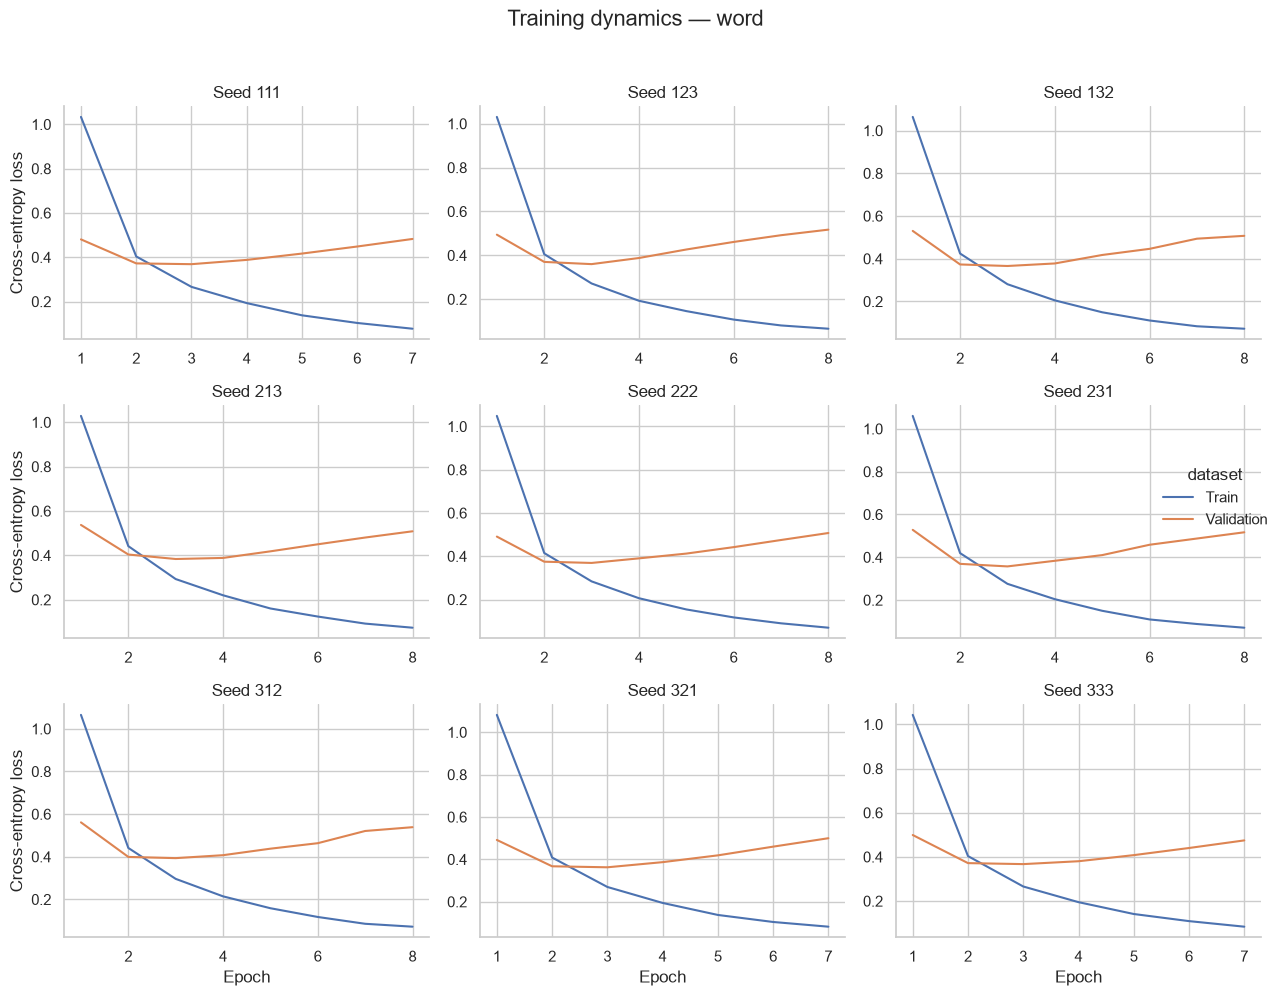

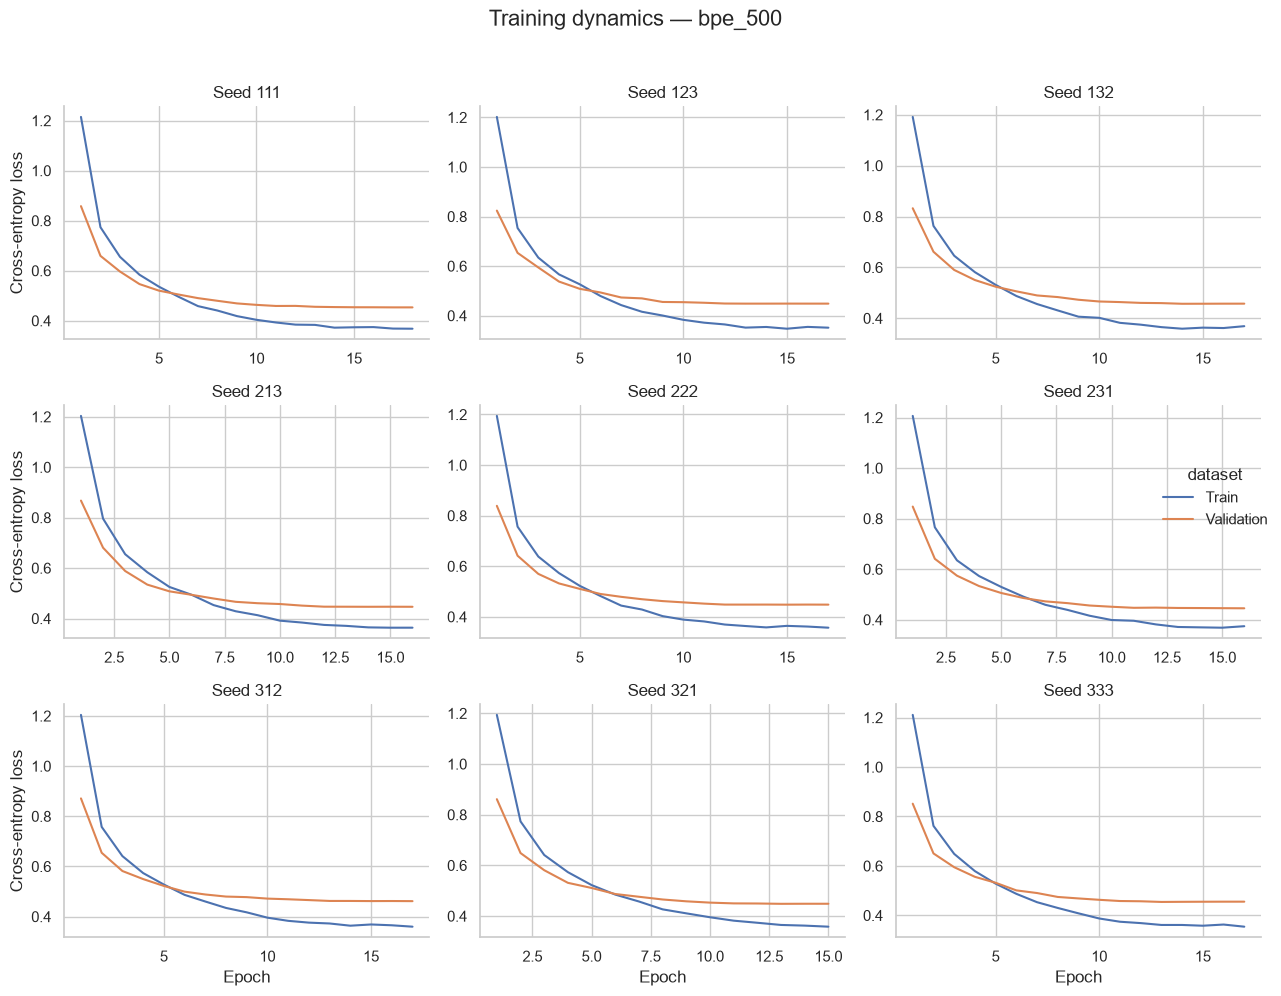

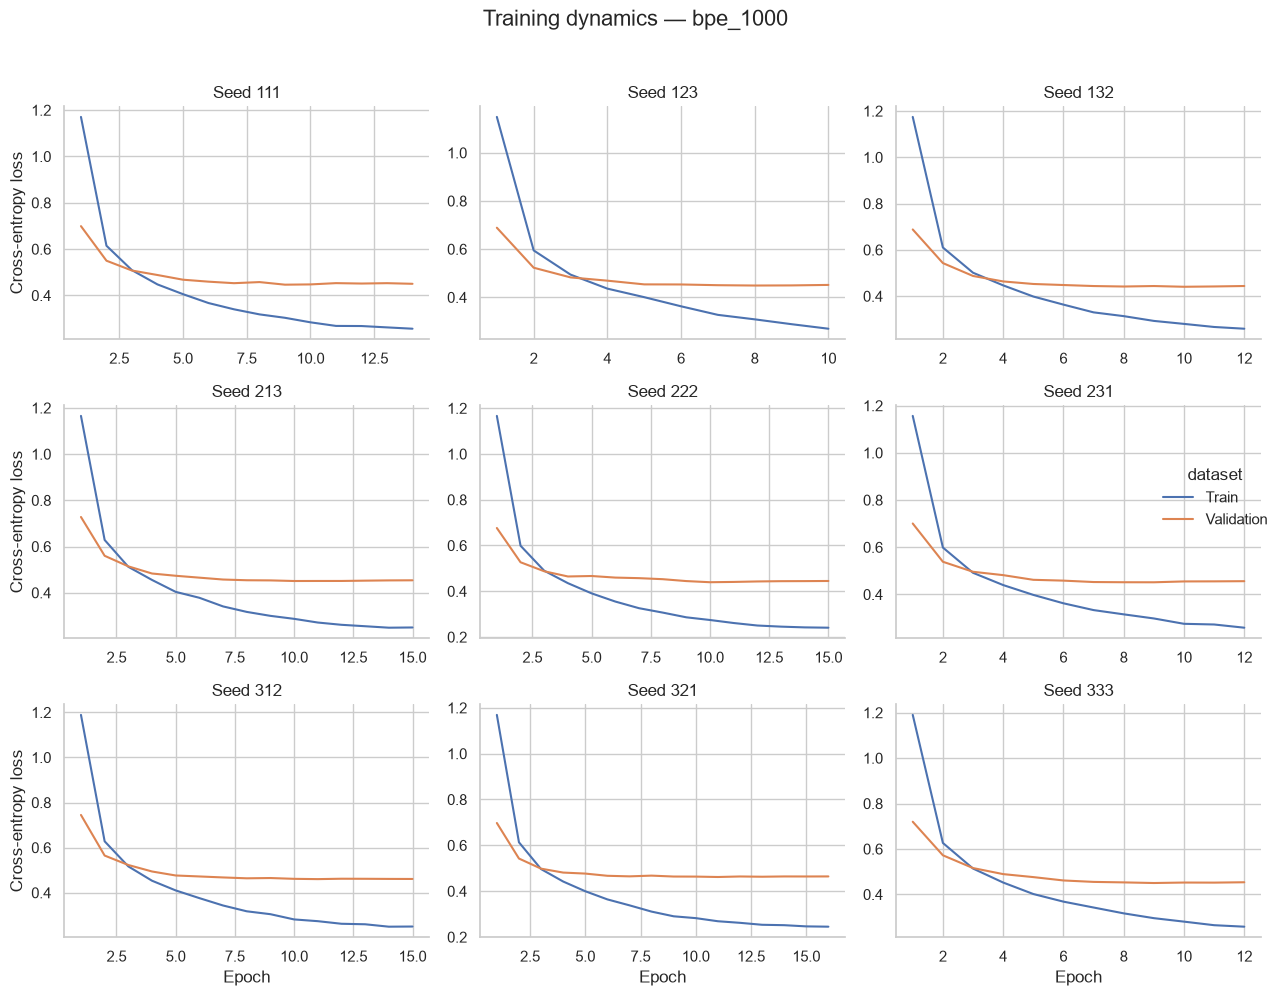

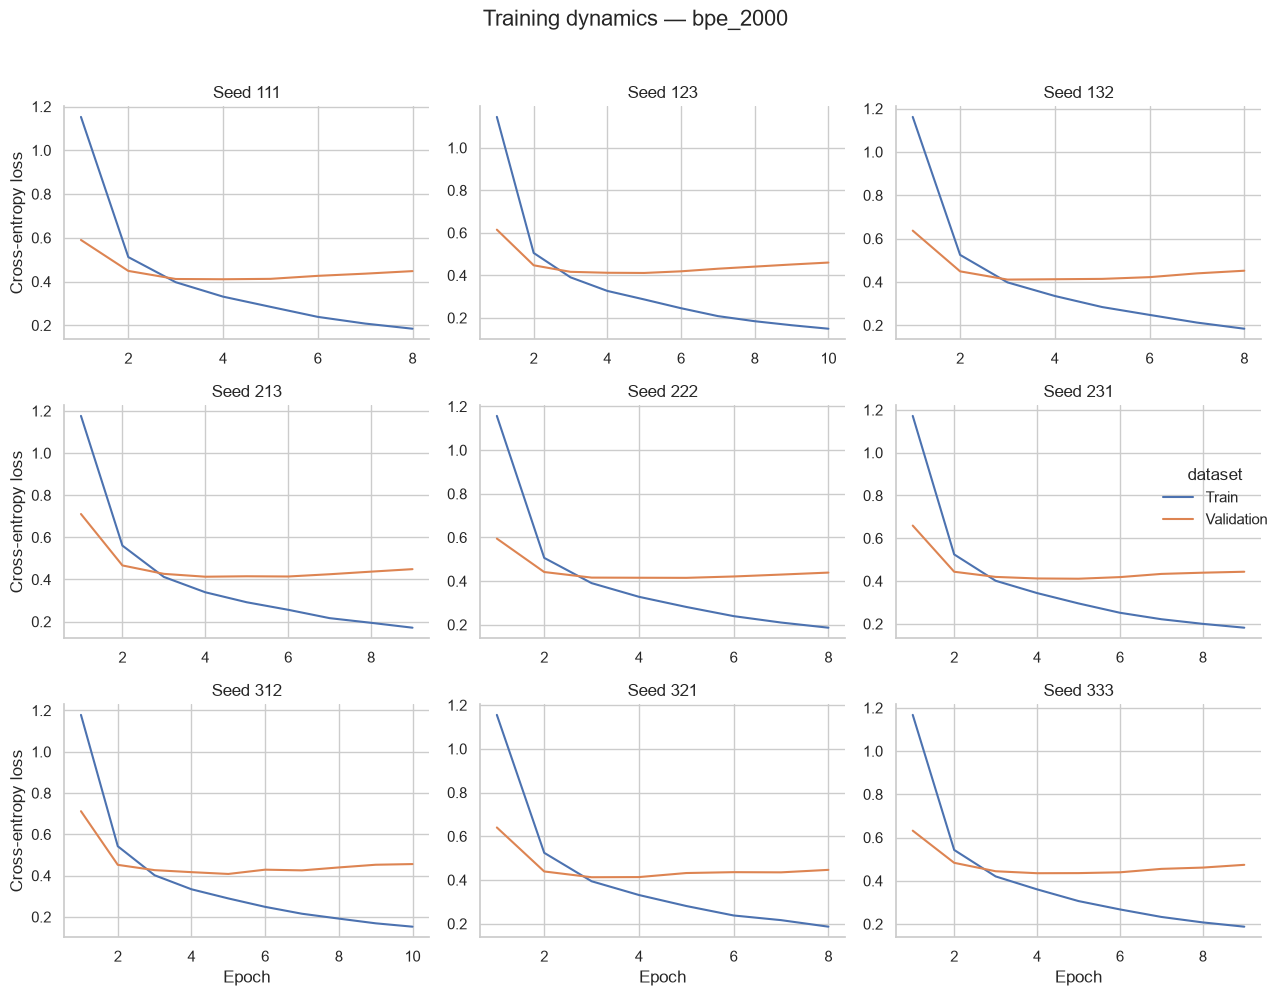

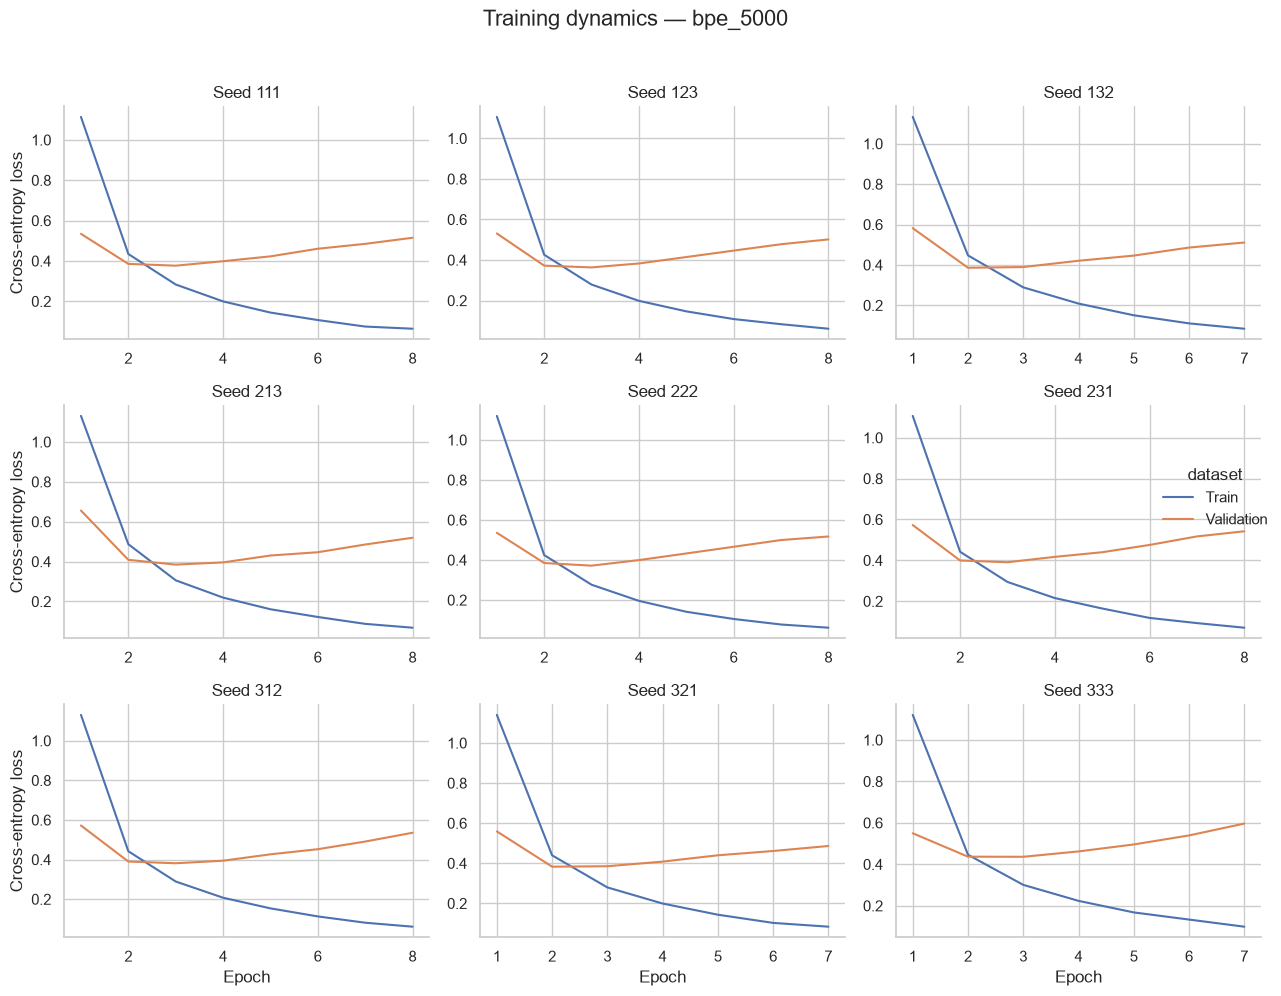

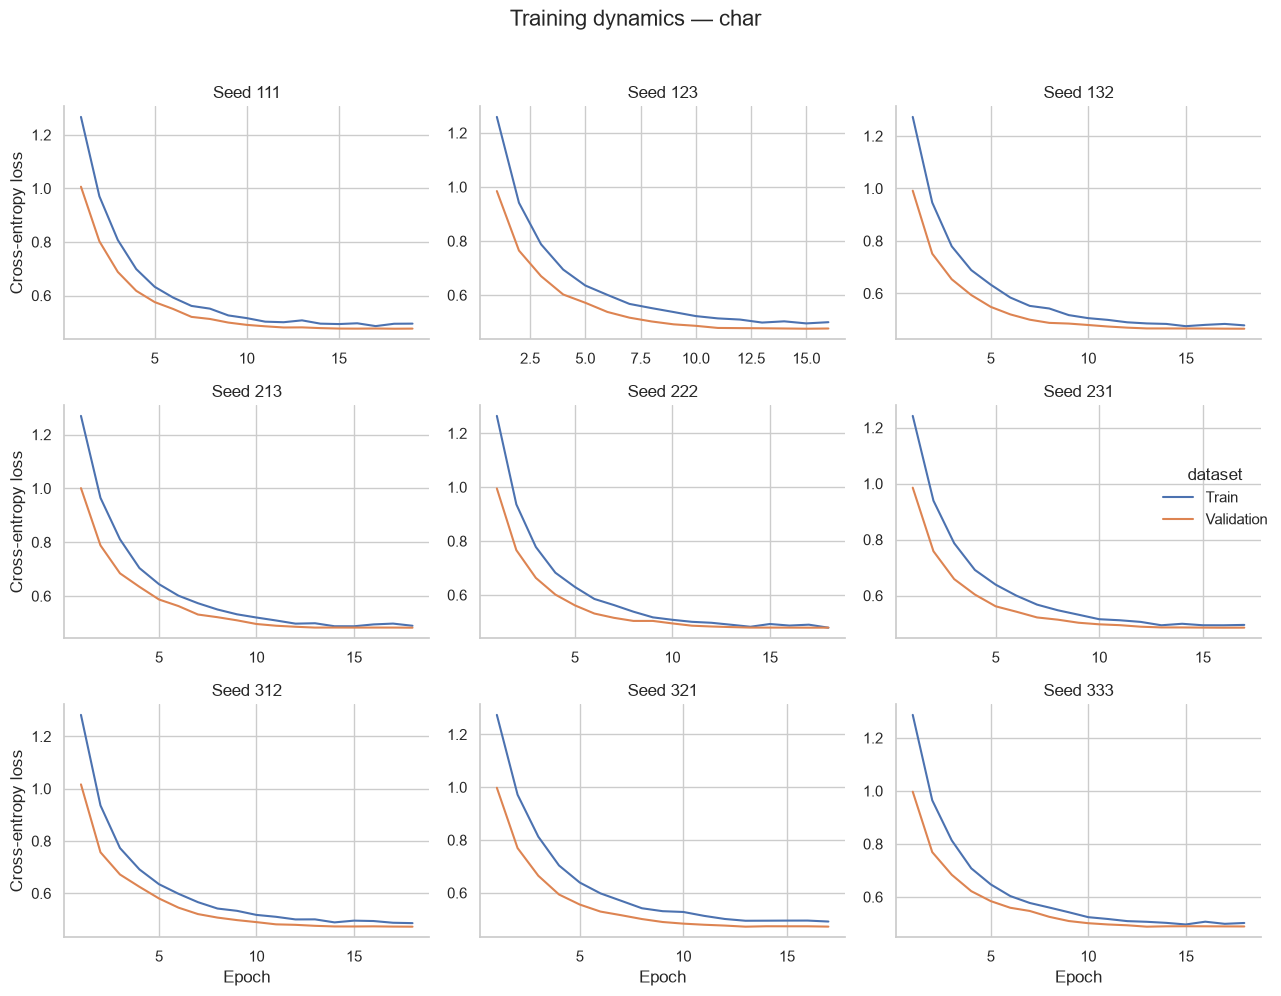

In [88]:
history_frames = []

for model_name in EXPERIMENTS:
    for seed in TRAINING_SEEDS:
        history_df = pd.read_csv(os.path.join(HISTORIES_DIR, f'{model_name}_seed{seed}_{RUN_ID}.csv'))
        history_df['model'] = model_name
        history_df['seed'] = seed
        history_frames.append(history_df)

histories_df = pd.concat(history_frames, ignore_index=True)

loss_df = histories_df.melt(id_vars=['model', 'seed', 'epoch'], value_vars=['loss', 'val_loss'], var_name='dataset', value_name='loss_value')
loss_df['dataset'] = loss_df['dataset'].map({'loss': 'Train', 'val_loss': 'Validation'})

for model_name in MODEL_ORDER:
    model_loss_df = loss_df[loss_df['model'].eq(model_name)]
    g = sns.relplot(
        data=model_loss_df,
        x='epoch',
        y='loss_value',
        hue='dataset',
        col='seed',
        col_wrap=3,
        kind='line',
        height=3.25,
        aspect=1.2,
        facet_kws={'sharex': False, 'sharey': False},
    )
    g.set_axis_labels('Epoch', 'Cross-entropy loss')
    g.set_titles('Seed {col_name}')
    g.figure.suptitle(f'Training dynamics — {model_name}', fontsize=16, y=1.02)
    plt.tight_layout()
    save_figure(g.figure, f'training_dynamics_{model_name}')
    plt.show()

In [89]:
metrics_df = pd.DataFrame(metric_rows)
resource_usage_df = pd.DataFrame(resource_rows)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

display(metrics_df.sort_values(['model', 'seed', 'corruption_level']))

display(
    metrics_df.groupby(['model', 'corruption_level'], as_index=False).agg(
        accuracy_mean=('accuracy', 'mean'),
        accuracy_std=('accuracy', 'std'),
        f1_macro_mean=('f1_macro', 'mean'),
        f1_macro_std=('f1_macro', 'std'),
        mcc_mean=('mcc', 'mean'),
        mcc_std=('mcc', 'std'),
    )
)

display(resource_usage_df)

,model,seed,corruption_level,n_samples,accuracy,precision_macro,f1_macro,mcc,log_loss,inference_time_s,inference_time_per_sample_ms
264,bpe_1000,111,0,2000,0.8215,0.821858,0.820743,0.762579,0.521329,0.188224,0.094112
265,bpe_1000,111,5,2000,0.8145,0.815725,0.813489,0.753654,0.540010,0.160761,0.080381
266,bpe_1000,111,10,2000,0.8095,0.810918,0.808532,0.747037,0.559521,0.156987,0.078493
267,bpe_1000,111,15,2000,0.8040,0.805042,0.803165,0.739500,0.573246,0.171840,0.085920
268,bpe_1000,111,20,2000,0.7950,0.796607,0.793995,0.727740,0.591335,0.152277,0.076139
...,...,...,...,...,...,...,...,...,...,...,...
94,word,333,30,2000,0.8240,0.825906,0.823731,0.766086,0.508259,0.236982,0.118491
95,word,333,35,2000,0.8110,0.813516,0.810863,0.748876,0.531465,0.178316,0.089158
96,word,333,40,2000,0.8035,0.807009,0.803531,0.739106,0.558965,0.159196,0.079598
97,word,333,45,2000,0.7915,0.796635,0.791708,0.723515,0.591484,0.163518,0.081759


,model,corruption_level,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std
0,bpe_1000,0,0.815444,0.005144,0.814726,0.005233,0.754598,0.006753
1,bpe_1000,5,0.809278,0.006852,0.808476,0.006867,0.746533,0.009108
2,bpe_1000,10,0.803500,0.006657,0.802826,0.006701,0.738823,0.008756
3,bpe_1000,15,0.798778,0.009162,0.798277,0.009133,0.732539,0.012178
4,bpe_1000,20,0.793167,0.008832,0.792711,0.008779,0.725115,0.011821
...,...,...,...,...,...,...,...,...
61,word,30,0.813667,0.008789,0.813169,0.008750,0.753551,0.011068
62,word,35,0.802278,0.010341,0.801848,0.010256,0.738919,0.012860
63,word,40,0.790222,0.011686,0.789841,0.011523,0.724021,0.013800
64,word,45,0.774944,0.015040,0.774561,0.014827,0.704792,0.017997


,model,seed,n_parameters,epochs_trained,restored_epoch,training_time_s,training_time_per_epoch_s,initial_ram_mb,peak_ram_mb,ram_increase_mb
0,word,123,189124,8,3,15.703893,1.962987,1186.597656,1216.957031,30.359375
1,word,132,189124,8,3,17.082429,2.135304,1215.718750,1228.175781,12.457031
2,word,213,189124,8,3,20.666627,2.583328,1221.234375,1231.863281,10.628906
3,word,231,189124,8,3,24.135435,3.016929,1223.796875,1235.863281,12.066406
4,word,321,189124,7,2,21.542526,3.077504,1227.222656,1237.992188,10.769531
5,word,312,189124,8,3,25.807992,3.225999,1230.054688,1240.914062,10.859375
6,word,111,189124,7,2,19.763491,2.823356,1233.070312,1243.421875,10.351562
7,word,222,189124,8,3,21.190091,2.648761,1234.699219,1245.031250,10.332031
8,word,333,189124,7,2,31.952842,4.564692,1236.222656,1245.980469,9.757812
9,bpe_500,123,45124,17,12,62.692886,3.687817,1238.238281,1258.726562,20.488281


# 5. Analysis

## 5.1 Visualization

In [90]:
sns.set_theme(style='whitegrid')


def plot_seed_mean_lines(ax, data, y, *, legend=False, zero_line=False, percentage=False):
    """Plot individual seed trajectories and the across-seed mean for a robustness metric."""
    sns.lineplot(
        data=data,
        x='corruption_level',
        y=y,
        hue='model',
        hue_order=MODEL_ORDER,
        units='seed',
        estimator=None,
        alpha=0.3,
        linewidth=1,
        legend=False,
        ax=ax,
    )
    sns.lineplot(
        data=data,
        x='corruption_level',
        y=y,
        hue='model',
        hue_order=MODEL_ORDER,
        estimator='mean',
        errorbar=None,
        marker='o',
        linewidth=2.5,
        legend=legend,
        ax=ax,
    )

    if zero_line:
        ax.axhline(0, linestyle='--', linewidth=1)
    if percentage:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    ax.set_xlabel('Corruption level (%)')
    ax.set_xticks(CORRUPTION_LEVELS)

In [91]:
analysis_df = metrics_df.melt(id_vars=['model', 'seed', 'corruption_level'], value_vars=list(METRICS), var_name='metric', value_name='performance')

clean_df = (analysis_df.loc[analysis_df['corruption_level'].eq(0), ['model', 'seed', 'metric', 'performance']].rename(columns={'performance': 'clean_performance'}))

analysis_df = analysis_df.merge(clean_df, on=['model', 'seed', 'metric'], how='left')

analysis_df['abs_degradation'] = np.where(analysis_df['metric'].eq('log_loss'), analysis_df['performance'] - analysis_df['clean_performance'], analysis_df['clean_performance'] - analysis_df['performance'])

analysis_df['rel_degradation'] = np.nan

higher_is_better_relative = analysis_df['metric'].isin(['accuracy', 'f1_macro'])
analysis_df.loc[higher_is_better_relative, 'rel_degradation'] = (analysis_df.loc[higher_is_better_relative, 'clean_performance'] - analysis_df.loc[higher_is_better_relative, 'performance']) / analysis_df.loc[higher_is_better_relative, 'clean_performance']

log_loss_mask = analysis_df['metric'].eq('log_loss')
analysis_df.loc[log_loss_mask, 'rel_degradation'] = (analysis_df.loc[log_loss_mask, 'performance'] - analysis_df.loc[log_loss_mask, 'clean_performance']) / analysis_df.loc[log_loss_mask, 'clean_performance']

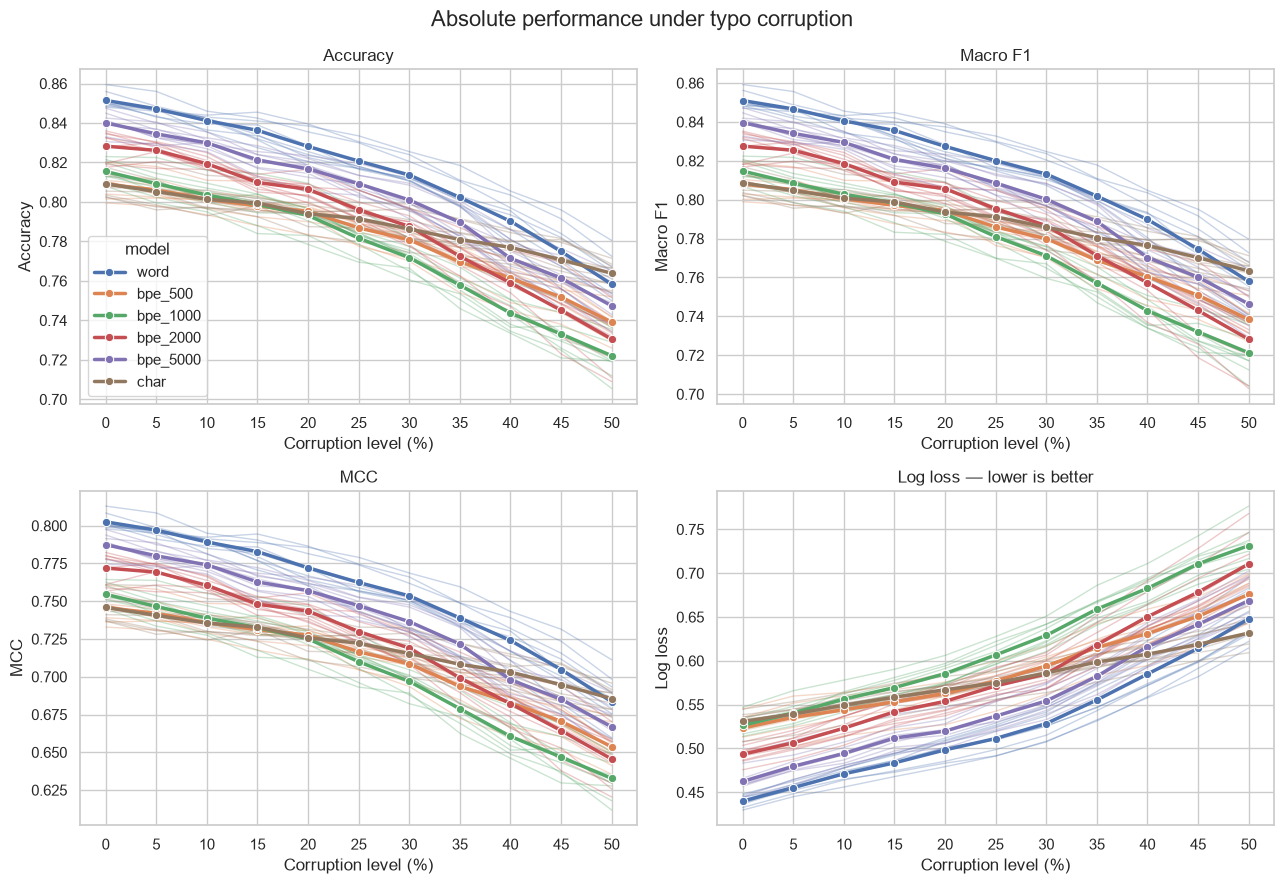

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (metric, label) in zip(axes.flat, METRICS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'performance', legend=(metric == 'accuracy'))

    ax.set_title(label)
    ax.set_ylabel(label)

axes[1, 1].set_title('Log loss — lower is better')

fig.suptitle('Absolute performance under typo corruption', fontsize=16)
plt.tight_layout()
save_figure(fig, 'absolute_performance')
plt.show()


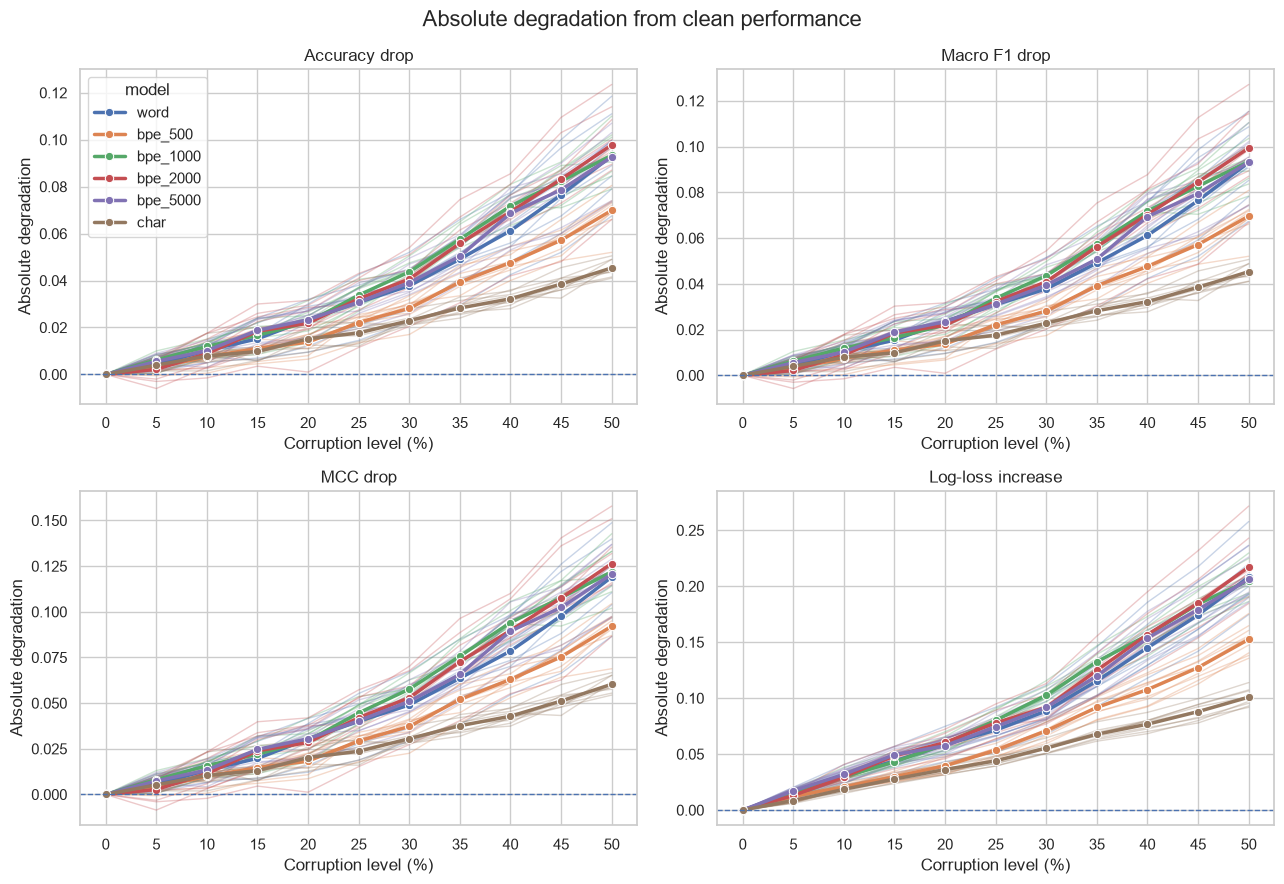

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (metric, label) in zip(axes.flat, ABS_DEGRADATION_LABELS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'abs_degradation', legend=(metric == 'accuracy'), zero_line=True)

    ax.set_title(label)
    ax.set_ylabel('Absolute degradation')

fig.suptitle('Absolute degradation from clean performance', fontsize=16)
plt.tight_layout()
save_figure(fig, 'absolute_degradation')
plt.show()

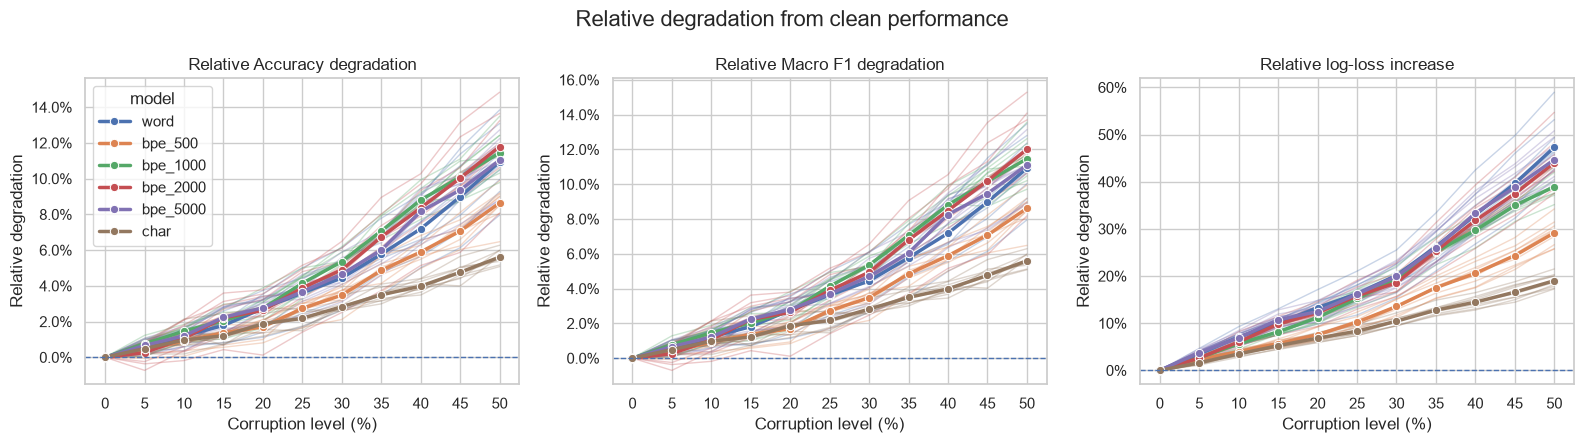

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (metric, label) in zip(axes, RELATIVE_METRICS.items()):
    plot_df = analysis_df[analysis_df['metric'].eq(metric)]
    plot_seed_mean_lines(ax, plot_df, 'rel_degradation', legend=(metric == 'accuracy'), zero_line=True, percentage=True)

    title = 'Relative log-loss increase' if metric == 'log_loss' else f'Relative {label} degradation'
    ax.set_title(title)
    ax.set_ylabel('Relative degradation')

fig.suptitle('Relative degradation from clean performance', fontsize=16)
plt.tight_layout()
save_figure(fig, 'relative_degradation')
plt.show()

In [95]:
mean_f1_degradation_df = (analysis_df.loc[analysis_df['metric'].eq('f1_macro') & analysis_df['corruption_level'].gt(0)].groupby(['model', 'seed'], as_index=False)
    .agg(mean_abs_degradation=('abs_degradation', 'mean'), mean_rel_degradation=('rel_degradation', 'mean')))

In [96]:
f1_degradation_df = analysis_df.loc[analysis_df['metric'].eq('f1_macro'), ['model', 'seed', 'corruption_level', 'abs_degradation', 'rel_degradation']]
f1_degradation_wide_df = f1_degradation_df.pivot(
    index=['seed', 'corruption_level'],
    columns='model',
    values=['abs_degradation', 'rel_degradation'],
)

f1_delta_frames = []
for model_a, model_b in MODEL_PAIRS:
    pair_df = f1_degradation_wide_df.index.to_frame(index=False)
    pair_df['model_a'] = model_a
    pair_df['model_b'] = model_b
    pair_df['comparison'] = f'{model_a} minus {model_b}'
    pair_df['abs_degradation_delta'] = (f1_degradation_wide_df['abs_degradation'][model_a] - f1_degradation_wide_df['abs_degradation'][model_b]).to_numpy()
    pair_df['rel_degradation_delta'] = (f1_degradation_wide_df['rel_degradation'][model_a] - f1_degradation_wide_df['rel_degradation'][model_b]).to_numpy()
    f1_delta_frames.append(pair_df)

f1_delta_df = pd.concat(f1_delta_frames, ignore_index=True)

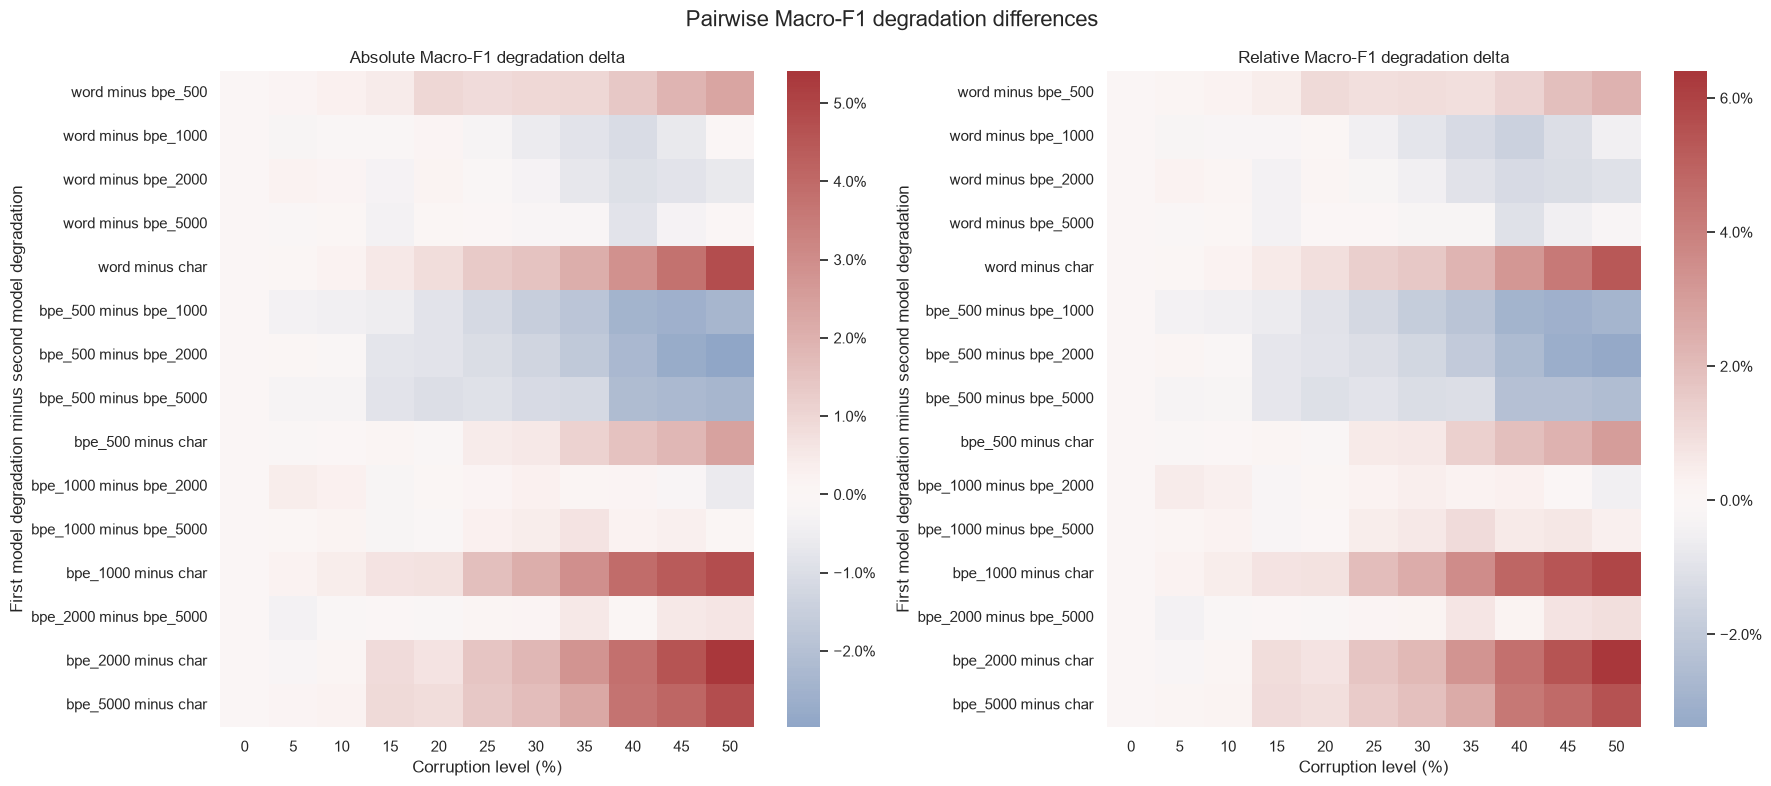

In [97]:
mean_f1_delta_df = (f1_delta_df.groupby(['comparison', 'corruption_level'], as_index=False)
    .agg(abs_degradation_delta=('abs_degradation_delta', 'mean'), rel_degradation_delta=('rel_degradation_delta', 'mean')))
comparison_order = [f'{model_a} minus {model_b}' for model_a, model_b in MODEL_PAIRS]

fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(MODEL_PAIRS) * 0.5)))
delta_plots = [('abs_degradation_delta', 'Absolute Macro-F1 degradation delta'), ('rel_degradation_delta', 'Relative Macro-F1 degradation delta')]

for ax, (value, title) in zip(axes, delta_plots):
    heatmap_df = (mean_f1_delta_df.pivot(index='comparison', columns='corruption_level', values=value)
        .reindex(index=comparison_order, columns=CORRUPTION_LEVELS))
    sns.heatmap(heatmap_df, center=0, cmap='vlag', cbar_kws={'format': PercentFormatter(1.0)}, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Corruption level (%)')
    ax.set_ylabel('First model degradation minus second model degradation')

fig.suptitle('Pairwise Macro-F1 degradation differences', fontsize=16)
plt.tight_layout()
save_figure(fig, 'f1_degradation_delta')
plt.show()

In [98]:
final_result_df = mean_f1_degradation_df.pivot(index='seed', columns='model', values='mean_abs_degradation').reset_index()

for model_a, model_b in MODEL_PAIRS:
    final_result_df[f'delta_{model_a}_minus_{model_b}'] = final_result_df[model_a] - final_result_df[model_b]

final_result_df = final_result_df.rename(columns={model: f'mean_{model}_f1_degradation' for model in MODEL_ORDER})

display(final_result_df.round(4))

model,seed,mean_bpe_1000_f1_degradation,mean_bpe_2000_f1_degradation,mean_bpe_500_f1_degradation,mean_bpe_5000_f1_degradation,mean_char_f1_degradation,mean_word_f1_degradation,delta_word_minus_bpe_500,delta_word_minus_bpe_1000,delta_word_minus_bpe_2000,...,delta_bpe_500_minus_bpe_1000,delta_bpe_500_minus_bpe_2000,delta_bpe_500_minus_bpe_5000,delta_bpe_500_minus_char,delta_bpe_1000_minus_bpe_2000,delta_bpe_1000_minus_bpe_5000,delta_bpe_1000_minus_char,delta_bpe_2000_minus_bpe_5000,delta_bpe_2000_minus_char,delta_bpe_5000_minus_char
0,111,0.0466,0.0219,0.0217,0.0455,0.0192,0.0251,0.0034,-0.0215,0.0032,...,-0.0249,-0.0002,-0.0237,0.0025,0.0247,0.0012,0.0274,-0.0235,0.0027,0.0262
1,123,0.0424,0.0577,0.0307,0.0455,0.0232,0.0414,0.0107,-0.0010,-0.0163,...,-0.0117,-0.0270,-0.0148,0.0075,-0.0153,-0.0031,0.0192,0.0122,0.0345,0.0223
2,132,0.0449,0.0396,0.0284,0.0314,0.0229,0.0494,0.0210,0.0045,0.0097,...,-0.0165,-0.0113,-0.0030,0.0055,0.0053,0.0135,0.0220,0.0082,0.0167,0.0085
3,213,0.0427,0.0453,0.0332,0.0416,0.0200,0.0396,0.0064,-0.0031,-0.0056,...,-0.0095,-0.0120,-0.0083,0.0133,-0.0026,0.0011,0.0228,0.0037,0.0253,0.0216
4,222,0.0373,0.0436,0.0286,0.0446,0.0239,0.0505,0.0220,0.0132,0.0070,...,-0.0088,-0.0150,-0.0161,0.0046,-0.0062,-0.0073,0.0134,-0.0011,0.0197,0.0207
5,231,0.0471,0.0547,0.0295,0.0483,0.0223,0.0404,0.0109,-0.0068,-0.0143,...,-0.0176,-0.0252,-0.0188,0.0072,-0.0076,-0.0012,0.0249,0.0064,0.0324,0.0261
6,312,0.0428,0.0469,0.0314,0.0331,0.0207,0.0397,0.0083,-0.0031,-0.0073,...,-0.0114,-0.0156,-0.0017,0.0106,-0.0041,0.0097,0.0220,0.0138,0.0262,0.0124
7,321,0.0487,0.0453,0.0343,0.0499,0.0220,0.0454,0.0111,-0.0033,0.0001,...,-0.0144,-0.0110,-0.0155,0.0123,0.0034,-0.0011,0.0267,-0.0046,0.0233,0.0279
8,333,0.0428,0.0365,0.0310,0.0395,0.0250,0.0304,-0.0006,-0.0124,-0.0061,...,-0.0118,-0.0056,-0.0085,0.0059,0.0063,0.0033,0.0178,-0.0030,0.0115,0.0144


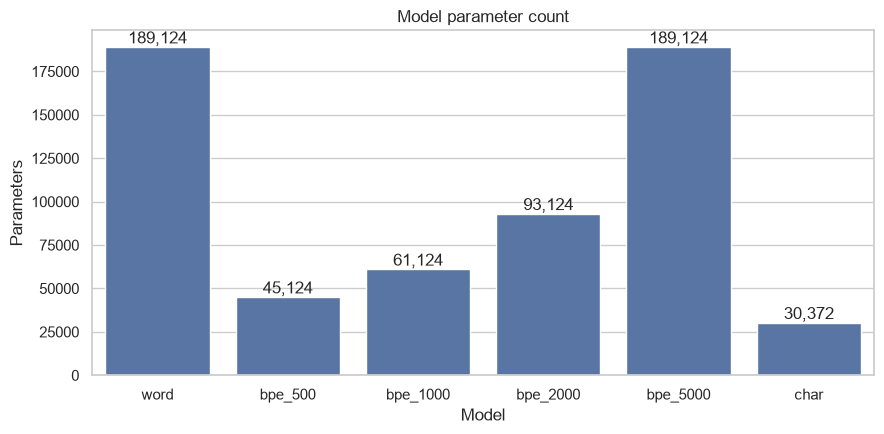

In [99]:
parameter_df = (resource_usage_df.groupby('model', as_index=False).agg(n_parameters=('n_parameters', 'first')))

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=parameter_df, x='model', y='n_parameters', order=MODEL_ORDER, ax=ax)

parameter_labels = (parameter_df.set_index('model').loc[MODEL_ORDER, 'n_parameters'].map(lambda value: f'{value:,.0f}'))
ax.bar_label(ax.containers[0], labels=parameter_labels)

ax.set_title('Model parameter count')
ax.set_xlabel('Model')
ax.set_ylabel('Parameters')

plt.tight_layout()
save_figure(fig, 'parameter_count')
plt.show()

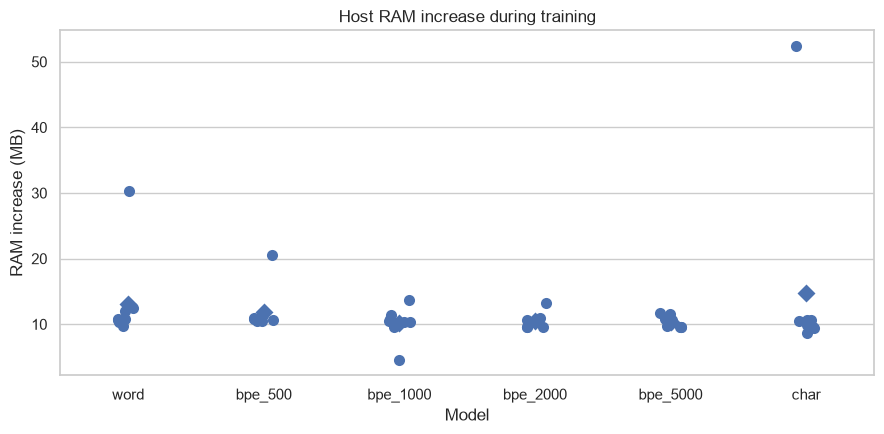

In [100]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.stripplot(
    data=resource_usage_df,
    x='model',
    y='ram_increase_mb',
    order=MODEL_ORDER,
    jitter=0.08,
    size=8,
    ax=ax,
)
sns.pointplot(
    data=resource_usage_df,
    x='model',
    y='ram_increase_mb',
    order=MODEL_ORDER,
    estimator='mean',
    errorbar=None,
    linestyle='none',
    marker='D',
    markersize=7,
    # capsize=0.15,
    ax=ax,
)

ax.set_title('Host RAM increase during training')
ax.set_xlabel('Model')
ax.set_ylabel('RAM increase (MB)')

plt.tight_layout()
save_figure(fig, 'ram_increase')
plt.show()

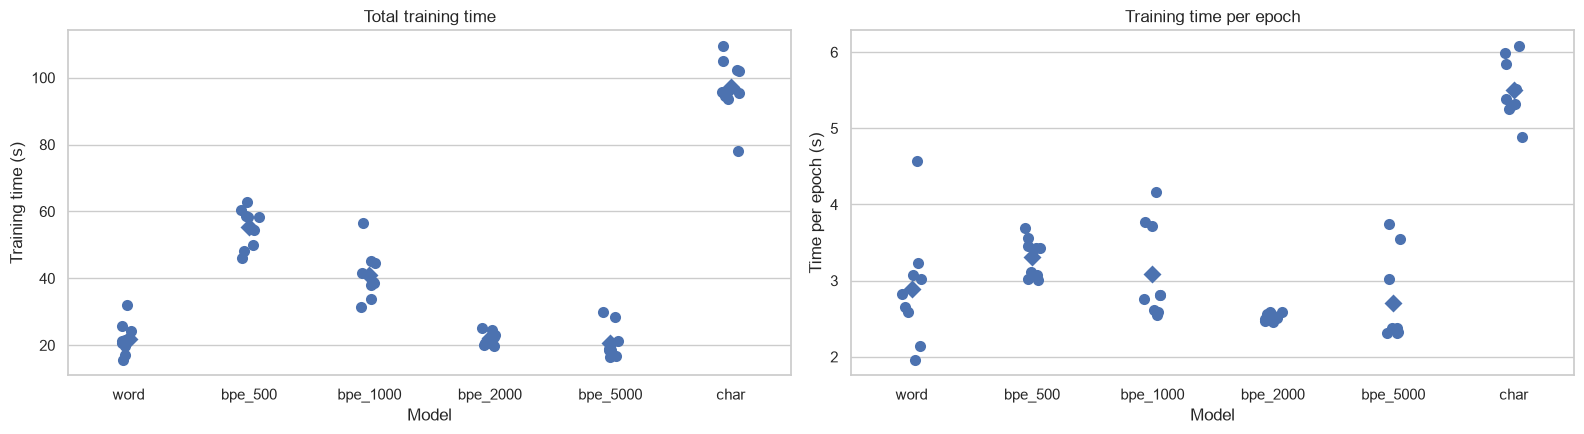

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

training_time_plots = [
    (
        'training_time_s',
        'Total training time',
        'Training time (s)',
    ),
    (
        'training_time_per_epoch_s',
        'Training time per epoch',
        'Time per epoch (s)',
    ),
]

for ax, (y, title, ylabel) in zip(axes, training_time_plots):
    sns.stripplot(
        data=resource_usage_df,
        x='model',
        y=y,
        order=MODEL_ORDER,
        jitter=0.08,
        size=8,
        ax=ax,
    )

    sns.pointplot(
        data=resource_usage_df,
        x='model',
        y=y,
        order=MODEL_ORDER,
        estimator='mean',
        errorbar=None,
        linestyle='none',
        marker='D',
        markersize=7,
        ax=ax,
    )

    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)

plt.tight_layout()
save_figure(fig, 'training_time')
plt.show()

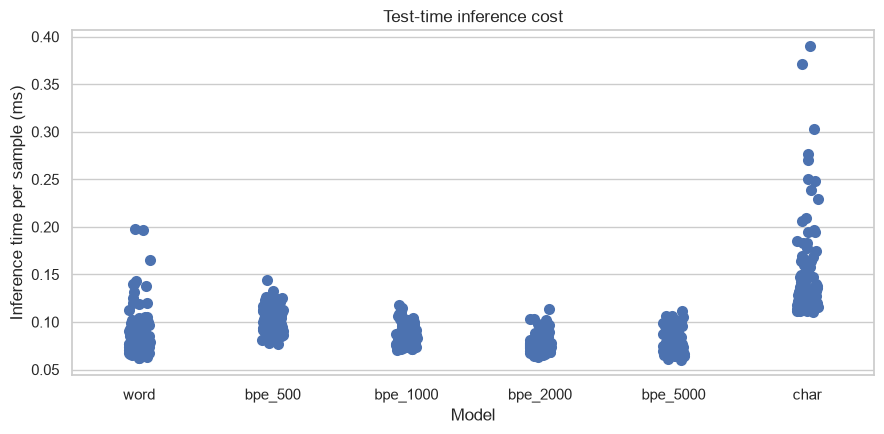

In [102]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sns.stripplot(
    data=metrics_df,
    x='model',
    y='inference_time_per_sample_ms',
    order=MODEL_ORDER,
    jitter=0.08,
    size=8,
    ax=ax,
)

sns.pointplot(
    data=metrics_df,
    x='model',
    y='inference_time_per_sample_ms',
    order=MODEL_ORDER,
    estimator='mean',
    errorbar=None,
    linestyle='none',
    marker='D',
    markersize=7,
    ax=ax,
)

ax.set_title('Test-time inference cost')
ax.set_xlabel('Model')
ax.set_ylabel('Inference time per sample (ms)')

plt.tight_layout()
save_figure(fig, 'inference_time')
plt.show()

## 5.2 Statistics

### 5.2.1 McNemar + Holm

In [103]:
mcnemar_rows = []

for seed in TRAINING_SEEDS:
    for corruption_level in CORRUPTION_LEVELS:
        paired_df = (predictions_df[(predictions_df['seed'] == seed) & (predictions_df['corruption_level'] == corruption_level)].pivot(index='sample_id', columns='model', values='correct',))
        for model_a, model_b in MODEL_PAIRS:
            model_a_correct = paired_df[model_a].astype(bool)
            model_b_correct = paired_df[model_b].astype(bool)

            both_correct = (model_a_correct & model_b_correct).sum()
            model_a_only_correct = (model_a_correct & ~model_b_correct).sum()
            model_b_only_correct = (~model_a_correct & model_b_correct).sum()
            both_wrong = (~model_a_correct & ~model_b_correct).sum()
            result = mcnemar([[both_correct, model_a_only_correct], [model_b_only_correct, both_wrong]], exact=True)

            mcnemar_rows.append({
                'seed': seed,
                'corruption_level': corruption_level,
                'model_a': model_a,
                'model_b': model_b,
                'n_samples': len(paired_df),
                'both_correct': both_correct,
                'model_a_only_correct': model_a_only_correct,
                'model_b_only_correct': model_b_only_correct,
                'both_wrong': both_wrong,
                'accuracy_delta_a_minus_b': (model_a_only_correct - model_b_only_correct) / len(paired_df),
                'p_raw': result.pvalue,
            })

mcnemar_df = pd.DataFrame(mcnemar_rows)

reject, p_holm, _, _ = multipletests(mcnemar_df['p_raw'], alpha=0.05, method='holm')

mcnemar_df['p_holm'] = p_holm
mcnemar_df['significant_holm_0.05'] = reject

mcnemar_df.to_csv(os.path.join(RESULTS_DIR, f'mcnemar_holm_{RUN_ID}.csv'), index=False)

display(mcnemar_df)

,seed,corruption_level,model_a,model_b,n_samples,both_correct,model_a_only_correct,model_b_only_correct,both_wrong,accuracy_delta_a_minus_b,p_raw,p_holm,significant_holm_0.05
0,123,0,word,bpe_500,2000,1532,169,108,191,0.0305,2.965604e-04,0.349052,False
1,123,0,word,bpe_1000,2000,1533,168,93,206,0.0375,4.015246e-06,0.005503,True
2,123,0,word,bpe_2000,2000,1562,139,103,196,0.0180,2.425578e-02,1.000000,False
3,123,0,word,bpe_5000,2000,1599,102,86,213,0.0080,2.739200e-01,1.000000,False
4,123,0,word,char,2000,1509,192,102,197,0.0450,1.694378e-07,0.000243,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,333,50,bpe_1000,bpe_5000,2000,1190,234,272,304,-0.0190,9.990529e-02,1.000000,False
1481,333,50,bpe_1000,char,2000,1236,188,301,275,-0.0565,3.647174e-07,0.000518,True
1482,333,50,bpe_2000,bpe_5000,2000,1268,196,194,342,0.0010,9.596234e-01,1.000000,False
1483,333,50,bpe_2000,char,2000,1279,185,258,278,-0.0365,6.085472e-04,0.690093,False


### 5.2.2 Relative Macro-F1 degradation

In [104]:
relative_f1_by_seed_df = (
    mean_f1_degradation_df
    .pivot(index='seed', columns='model', values='mean_rel_degradation')
    .dropna(subset=MODEL_ORDER)
    .reset_index()
)

relative_f1_test_rows = []
for model_a, model_b in MODEL_PAIRS:
    paired_deltas = (relative_f1_by_seed_df[model_a] - relative_f1_by_seed_df[model_b]).to_numpy()
    n_seeds = len(paired_deltas)
    if n_seeds == 0:
        raise ValueError('No paired seed results are available for the relative Macro-F1 test.')

    n_permutations = 2 ** n_seeds
    sign_bits = (np.arange(n_permutations)[:, None] >> np.arange(n_seeds)[None, :]) & 1
    signs = np.where(sign_bits == 0, -1.0, 1.0)
    permuted_mean_deltas = (signs * paired_deltas).mean(axis=1)
    observed_mean_delta = paired_deltas.mean()
    p_value_two_sided = np.mean(np.abs(permuted_mean_deltas) >= np.abs(observed_mean_delta) - 1e-12)

    relative_f1_test_rows.append({
        'test': 'Exact paired sign-flip permutation test',
        'metric': 'Mean relative Macro-F1 degradation',
        'model_a': model_a,
        'model_b': model_b,
        'n_seeds': n_seeds,
        'observed_mean_delta_a_minus_b': observed_mean_delta,
        'n_exact_permutations': n_permutations,
        'p_raw': p_value_two_sided,
    })

relative_f1_test_result_df = pd.DataFrame(relative_f1_test_rows)
reject, p_holm, _, _ = multipletests(relative_f1_test_result_df['p_raw'], alpha=0.05, method='holm')
relative_f1_test_result_df['p_holm'] = p_holm
relative_f1_test_result_df['significant_holm_0.05'] = reject

relative_f1_by_seed_df.to_csv(
    os.path.join(RESULTS_DIR, f'relative_f1_degradation_by_seed_{RUN_ID}.csv'),
    index=False,
)
relative_f1_test_result_df.to_csv(
    os.path.join(RESULTS_DIR, f'relative_f1_degradation_test_{RUN_ID}.csv'),
    index=False,
)

display(relative_f1_by_seed_df.round(4))
display(relative_f1_test_result_df)

model,seed,bpe_1000,bpe_2000,bpe_500,bpe_5000,char,word
0,111,0.0568,0.0269,0.0271,0.0541,0.0239,0.0297
1,123,0.0522,0.0694,0.0375,0.0540,0.0288,0.0487
2,132,0.0551,0.0479,0.0354,0.0374,0.0279,0.0582
3,213,0.0521,0.0542,0.0411,0.0492,0.0249,0.0467
4,222,0.0454,0.0523,0.0352,0.0526,0.0298,0.0590
5,231,0.0582,0.0655,0.0365,0.0574,0.0274,0.0470
6,312,0.0530,0.0563,0.0393,0.0398,0.0258,0.0467
7,321,0.0598,0.0554,0.0423,0.0594,0.0272,0.0535
8,333,0.0527,0.0446,0.0383,0.0475,0.0306,0.0357


,test,metric,model_a,model_b,n_seeds,observed_mean_delta_a_minus_b,n_exact_permutations,p_raw,p_holm,significant_holm_0.05
0,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_500,9,0.010296,512,0.007812,0.062500,False
1,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_1000,9,-0.006689,512,0.121094,0.726562,False
2,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_2000,9,-0.005260,512,0.183594,0.917969,False
3,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_5000,9,-0.002931,512,0.519531,1.000000,False
4,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,char,9,0.019879,512,0.003906,0.058594,False
5,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_1000,9,-0.016985,512,0.003906,0.058594,False
6,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_2000,9,-0.015555,512,0.007812,0.062500,False
7,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_5000,9,-0.013226,512,0.003906,0.058594,False
8,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,char,9,0.009583,512,0.003906,0.058594,False
9,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_1000,bpe_2000,9,0.001430,512,0.765625,1.000000,False


### 5.2.3 BPE vocabulary-size omnibus test

In [106]:
friedman_result = friedmanchisquare(*(relative_f1_by_seed_df[model_name] for model_name in BPE_MODEL_NAMES))

bpe_friedman_df = pd.DataFrame([{
    'test': 'Friedman test',
    'metric': 'Mean relative Macro-F1 degradation',
    'models': ', '.join(BPE_MODEL_NAMES),
    'n_seeds': len(relative_f1_by_seed_df),
    'statistic': friedman_result.statistic,
    'p_value': friedman_result.pvalue,
    'significant_0.05': friedman_result.pvalue < 0.05,
}])

bpe_friedman_df.to_csv(
    os.path.join(RESULTS_DIR, f'bpe_vocabulary_friedman_{RUN_ID}.csv'),
    index=False,
)
display(bpe_friedman_df)

,test,metric,models,n_seeds,statistic,p_value,significant_0.05
0,Friedman test,Mean relative Macro-F1 degradation,"bpe_500, bpe_1000, bpe_2000, bpe_5000",9,14.733333,0.002059,True


### 5.2.4 BPE vocabulary-size post-hoc comparisons

In [107]:
def holm_correct_test_family(model_pairs, family_name: str):
    pair_order = {pair: index for index, pair in enumerate(model_pairs)}
    family_df = relative_f1_test_result_df[
        relative_f1_test_result_df[['model_a', 'model_b']].apply(tuple, axis=1).isin(pair_order)
    ].drop(columns=['p_holm', 'significant_holm_0.05'], errors='ignore').copy()

    family_df['pair_order'] = family_df[['model_a', 'model_b']].apply(tuple, axis=1).map(pair_order)
    family_df = family_df.sort_values('pair_order').drop(columns='pair_order').reset_index(drop=True)
    reject, p_holm, _, _ = multipletests(family_df['p_raw'], alpha=0.05, method='holm')
    family_df.insert(0, 'family', family_name)
    family_df['p_holm_family'] = p_holm
    family_df['significant_holm_0.05'] = reject
    return family_df


bpe_posthoc_df = holm_correct_test_family(
    list(combinations(BPE_MODEL_NAMES, 2)),
    'BPE vocabulary sizes',
)
bpe_posthoc_df.to_csv(
    os.path.join(RESULTS_DIR, f'bpe_vocabulary_posthoc_{RUN_ID}.csv'),
    index=False,
)
display(bpe_posthoc_df)

,family,test,metric,model_a,model_b,n_seeds,observed_mean_delta_a_minus_b,n_exact_permutations,p_raw,p_holm_family,significant_holm_0.05
0,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_1000,9,-0.016985,512,0.003906,0.023438,True
1,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_2000,9,-0.015555,512,0.007812,0.031250,True
2,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,bpe_5000,9,-0.013226,512,0.003906,0.023438,True
3,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_1000,bpe_2000,9,0.001430,512,0.765625,1.000000,False
4,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_1000,bpe_5000,9,0.003759,512,0.203125,0.609375,False
5,BPE vocabulary sizes,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_2000,bpe_5000,9,0.002329,512,0.625000,1.000000,False


### 5.2.5 Word versus BPE comparisons

In [108]:
word_vs_bpe_df = holm_correct_test_family(
    [('word', model_name) for model_name in BPE_MODEL_NAMES],
    'Word versus BPE',
)
word_vs_bpe_df.to_csv(
    os.path.join(RESULTS_DIR, f'word_vs_bpe_relative_f1_{RUN_ID}.csv'),
    index=False,
)
display(word_vs_bpe_df)

,family,test,metric,model_a,model_b,n_seeds,observed_mean_delta_a_minus_b,n_exact_permutations,p_raw,p_holm_family,significant_holm_0.05
0,Word versus BPE,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_500,9,0.010296,512,0.007812,0.031250,True
1,Word versus BPE,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_1000,9,-0.006689,512,0.121094,0.363281,False
2,Word versus BPE,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_2000,9,-0.005260,512,0.183594,0.367188,False
3,Word versus BPE,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,bpe_5000,9,-0.002931,512,0.519531,0.519531,False


### 5.2.6 BPE versus character comparisons

In [109]:
bpe_vs_char_df = holm_correct_test_family(
    [(model_name, 'char') for model_name in BPE_MODEL_NAMES],
    'BPE versus character',
)
bpe_vs_char_df.to_csv(
    os.path.join(RESULTS_DIR, f'bpe_vs_char_relative_f1_{RUN_ID}.csv'),
    index=False,
)
display(bpe_vs_char_df)

,family,test,metric,model_a,model_b,n_seeds,observed_mean_delta_a_minus_b,n_exact_permutations,p_raw,p_holm_family,significant_holm_0.05
0,BPE versus character,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_500,char,9,0.009583,512,0.003906,0.015625,True
1,BPE versus character,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_1000,char,9,0.026568,512,0.003906,0.015625,True
2,BPE versus character,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_2000,char,9,0.025139,512,0.003906,0.015625,True
3,BPE versus character,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,bpe_5000,char,9,0.022810,512,0.003906,0.015625,True


### 5.2.7 Word versus character comparison

In [110]:
word_vs_char_df = holm_correct_test_family(
    [('word', 'char')],
    'Word versus character',
)
word_vs_char_df.to_csv(
    os.path.join(RESULTS_DIR, f'word_vs_char_relative_f1_{RUN_ID}.csv'),
    index=False,
)
display(word_vs_char_df)

,family,test,metric,model_a,model_b,n_seeds,observed_mean_delta_a_minus_b,n_exact_permutations,p_raw,p_holm_family,significant_holm_0.05
0,Word versus character,Exact paired sign-flip permutation test,Mean relative Macro-F1 degradation,word,char,9,0.019879,512,0.003906,0.003906,True
